## Splitting dataset into labeled (65k) and unlabeled (30k) sets.

In [2]:
!pip install xgboost optuna scikit-learn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/synthetic_insurance_claims_with_fraud_3%_label.csv').drop(columns=['fraud_probability_score'])
print(f"Total number of columns in df: {df.shape[1]}")
print(f"Total no of rows in df: {df.shape[0]}")
print(df.columns)

# Ensure 'fraud_label' is of integer type and handle potential NaNs
# sklearn's train_test_split with stratify does not accept NaN values.
if df['fraud_label'].isnull().any():
    nan_count = df['fraud_label'].isnull().sum()
    print(f"Warning: 'fraud_label' column contains {nan_count} NaN values. Filling with 0 to enable stratification.")
    df['fraud_label'] = df['fraud_label'].fillna(0).astype(int)
else:
    # If no NaNs, ensure it's still an integer type to prevent potential issues
    # with mixed types or float representation if read_csv inferred float.
    df['fraud_label'] = df['fraud_label'].astype(int)

print('% of fraud in data = ', df['fraud_label'].sum() / len(df) * 100)

df_labeled, df_unlabeled = train_test_split(df, test_size=30000, random_state=42, stratify=df['fraud_label'])

print('% of fraud in labeled_data = ', len(df_labeled), df_labeled['fraud_label'].sum() / len(df_labeled) * 100)
print('% of fraud in unlabeled_data = ', len(df_unlabeled), df_unlabeled['fraud_label'].sum() / len(df_unlabeled) * 100)

df_labeled.to_csv('labeled_synthetic_insurance_claims_with_fraud_3%_label.csv', index=False)
df_unlabeled.to_csv('unlabeled_synthetic_insurance_claims_with_fraud_3%_label.csv', index=False)

Total number of columns in df: 44
Total no of rows in df: 95000
Index(['claim_days_differenc', 'claim_loss_date_dom',
       'claim_loss_datet_to_policy_ply_icp_dt_delta',
       'claim_loss_date_to_policy_str_date_delta', 'claim_loss_type_ab',
       'claim_loss_type_ad', 'claim_loss_type_al', 'claim_loss_type_eo',
       'claim_loss_type_es', 'claim_loss_type_ew', 'claim_loss_type_fi',
       'claim_loss_type_fl', 'claim_loss_type_gm', 'claim_loss_type_im',
       'claim_loss_type_lb', 'claim_loss_type_mc', 'claim_loss_type_md',
       'claim_loss_type_rl', 'claim_loss_type_st', 'claim_loss_type_th',
       'claim_number', 'claim_report_date_to_policy_ori_qte_dt_delta',
       'sum_insured', 'reinstatement_value', 'credit_risk_score',
       'total_active_associate_cai', 'barriers_wide_score',
       'children_population', 'insurance_indicator', 'oc_code', 'policy_api',
       'policy_claim_free_year', 'policy_cld_cst1_aggregate',
       'policy_ply_icp_dt_to_cust_cst_brt_dt_delta', 

## Baseline models

### Case 1: Train (45k), val (10k) and test (10k) from labeled set only

In [4]:
c1_train_data, c1_val_data = train_test_split(df_labeled, test_size=20000, random_state=42, stratify=df_labeled['fraud_label'])
c1_test_data, c1_val_data = train_test_split(c1_val_data, test_size=10000, random_state=42, stratify=c1_val_data['fraud_label'])

#### Accuracy based models

In [5]:
import optuna
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, auc, log_loss)

def accuracy_based_baselines(train_data, val_data, test_data):
    # Define target column
    TARGET = 'fraud_label'

    # Split into features and labels
    X_train, y_train = train_data.drop(columns=[TARGET]), train_data[TARGET]
    X_val, y_val     = val_data.drop(columns=[TARGET]), val_data[TARGET]
    X_test, y_test   = test_data.drop(columns=[TARGET]), test_data[TARGET]

    # 1. Calculate Imbalance Weights
    # For XGBoost: ratio of negative to positive samples
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    warnings.filterwarnings("ignore", category=UserWarning) # Suppress convergence warnings during plotting

    # --- Logistic Regression Tuning ---
    def objective_lr(trial):
        C = trial.suggest_float('C', 1e-4, 10.0, log=True)
        solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear'])

        model = LogisticRegression(C=C, solver=solver, class_weight='balanced', max_iter=1000, random_state=42)
        model.fit(X_train, y_train)

        probs = model.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, probs)

    study_lr = optuna.create_study(direction='maximize')
    study_lr.optimize(objective_lr, n_trials=10)
    print(f"Best LR Params: {study_lr.best_params}")

    # --- Decision Tree Tuning ---
    def objective_dt(trial):
        max_depth = trial.suggest_int('max_depth', 3, 15)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)

        model = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split,
                                       class_weight='balanced', random_state=42)
        model.fit(X_train, y_train)

        probs = model.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, probs)

    study_dt = optuna.create_study(direction='maximize')
    study_dt.optimize(objective_dt, n_trials=10)
    print(f"Best DT Params: {study_dt.best_params}")

    # --- Random Forest Tuning ---
    def objective_rf(trial):
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 15)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)

        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,
                                       min_samples_split=min_samples_split, class_weight='balanced',
                                       random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)

        probs = model.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, probs)

    study_rf = optuna.create_study(direction='maximize')
    study_rf.optimize(objective_rf, n_trials=10)
    print(f"Best RF Params: {study_rf.best_params}")

    # --- XGBoost Tuning ---
    def objective_xgb(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'scale_pos_weight': scale_pos_weight,
            'random_state': 42,
            'eval_metric': 'logloss'
        }

        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        probs = model.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, probs)

    study_xgb = optuna.create_study(direction='maximize')
    study_xgb.optimize(objective_xgb, n_trials=10)
    print(f"Best XGB Params: {study_xgb.best_params}")

    # --- Train Final Models ---

    # 1. Logistic Regression
    best_lr = LogisticRegression(**study_lr.best_params, class_weight='balanced', max_iter=1000, random_state=42)
    best_lr.fit(X_train, y_train)
    lr_preds = best_lr.predict(X_test)
    lr_probs = best_lr.predict_proba(X_test)[:, 1]

    # Custom loop to extract simulated epoch loss for LR
    lr_train_loss, lr_val_loss = [], []
    lr_epochs = list(range(1, 101, 5))
    for epochs in lr_epochs:
        temp_lr = LogisticRegression(**study_lr.best_params, class_weight='balanced', max_iter=epochs, random_state=42)
        temp_lr.fit(X_train, y_train)
        lr_train_loss.append(log_loss(y_train, temp_lr.predict_proba(X_train)))
        lr_val_loss.append(log_loss(y_val, temp_lr.predict_proba(X_val)))

    # 2. Decision Tree (Single-shot algorithm, tracking static final loss for plotting)
    best_dt = DecisionTreeClassifier(**study_dt.best_params, class_weight='balanced', random_state=42)
    best_dt.fit(X_train, y_train)
    dt_preds = best_dt.predict(X_test)
    dt_probs = best_dt.predict_proba(X_test)[:, 1]

    dt_train_loss = log_loss(y_train, best_dt.predict_proba(X_train))
    dt_val_loss = log_loss(y_val, best_dt.predict_proba(X_val))

    # 3. Random Forest
    best_rf = RandomForestClassifier(**study_rf.best_params, class_weight='balanced', random_state=42, n_jobs=-1)
    best_rf.fit(X_train, y_train)
    rf_preds = best_rf.predict(X_test)
    rf_probs = best_rf.predict_proba(X_test)[:, 1]

    # Custom loop to extract simulated estimator loss for RF
    rf_train_loss, rf_val_loss = [], []
    rf_epochs = list(range(1, study_rf.best_params['n_estimators'] + 1, max(1, study_rf.best_params['n_estimators'] // 20)))
    for estimators in rf_epochs:
        rf_params = study_rf.best_params.copy()
        rf_params['n_estimators'] = estimators
        temp_rf = RandomForestClassifier(**rf_params, class_weight='balanced', random_state=42, n_jobs=-1)
        temp_rf.fit(X_train, y_train)
        rf_train_loss.append(log_loss(y_train, temp_rf.predict_proba(X_train)))
        rf_val_loss.append(log_loss(y_val, temp_rf.predict_proba(X_val)))

    # 4. XGBoost
    best_xgb = xgb.XGBClassifier(**study_xgb.best_params, scale_pos_weight=scale_pos_weight,
                                random_state=42, eval_metric=['logloss'])
    best_xgb.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
    xgb_preds = best_xgb.predict(X_test)
    xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

    # --- Compile Test Set Metrics ---
    def get_metrics(y_true, y_pred, y_prob, model_name):
        return {
            'Model': model_name,
            'ROC-AUC': roc_auc_score(y_true, y_prob),
            'F1-Score': f1_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred)
        }

    results_df = pd.DataFrame([
        get_metrics(y_test, lr_preds, lr_probs, "Logistic Regression"),
        get_metrics(y_test, dt_preds, dt_probs, "Decision Tree"),
        get_metrics(y_test, rf_preds, rf_probs, "Random Forest"),
        get_metrics(y_test, xgb_preds, xgb_probs, "XGBoost")
    ])

    print("\n--- Final Test Set Performance ---")
    try:
        display(results_df)
    except NameError:
        print(results_df.to_string())

    # --- Plotting ---
    fig = plt.figure(figsize=(18, 16)) # Slightly taller to accommodate 3 rows natively
    sns.set_theme(style="whitegrid")

    # 1. Combined Learning Curves (Top row)
    ax1 = plt.subplot(3, 1, 1)

    # XGBoost
    xgb_results = best_xgb.evals_result()
    xgb_epochs = range(0, len(xgb_results['validation_0']['logloss']))
    ax1.plot(xgb_epochs, xgb_results['validation_0']['logloss'], label='XGB Train Loss', color='blue', linestyle='-')
    ax1.plot(xgb_epochs, xgb_results['validation_1']['logloss'], label='XGB Val Loss', color='cyan', linestyle='--')

    # Logistic Regression
    ax1.plot(lr_epochs, lr_train_loss, label='LR Train Loss', color='red', linestyle='-')
    ax1.plot(lr_epochs, lr_val_loss, label='LR Val Loss', color='orange', linestyle='--')

    # Random Forest
    ax1.plot(rf_epochs, rf_train_loss, label='RF Train Loss', color='green', linestyle='-')
    ax1.plot(rf_epochs, rf_val_loss, label='RF Val Loss', color='lime', linestyle='--')

    # Decision Tree (Horizontal lines as it is non-iterative)
    ax1.axhline(dt_train_loss, label='DT Train Loss (Static)', color='purple', linestyle='-')
    ax1.axhline(dt_val_loss, label='DT Val Loss (Static)', color='magenta', linestyle='--')

    ax1.set_title('Combined Learning Curves: All Models (Log Loss)')
    ax1.set_xlabel('Iterations / Boosting Rounds / Estimators')
    ax1.set_ylabel('Log Loss')
    ax1.legend(loc='upper right')

    # Data lists for automated plotting loops
    models_data = [
        ("Logistic Regression", lr_probs, lr_preds),
        ("Decision Tree", dt_probs, dt_preds),
        ("Random Forest", rf_probs, rf_preds),
        ("XGBoost", xgb_probs, xgb_preds)
    ]

    # 2. Precision-Recall Curve (Middle Left)
    ax2 = plt.subplot(3, 2, 3)
    for model_name, probs, _ in models_data:
        precision, recall, _ = precision_recall_curve(y_test, probs)
        pr_auc = auc(recall, precision)
        ax2.plot(recall, precision, label=f'{model_name} (AUC={pr_auc:.3f})')

    ax2.set_title('Precision-Recall Curve (Test Set)')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.legend()

    # 3. ROC Curve (Middle Right)
    ax3 = plt.subplot(3, 2, 4)
    for model_name, probs, _ in models_data:
        fpr, tpr, _ = roc_curve(y_test, probs)
        roc_auc = roc_auc_score(y_test, probs)
        ax3.plot(fpr, tpr, label=f'{model_name} (AUC={roc_auc:.3f})')

    ax3.plot([0, 1], [0, 1], 'k--')
    ax3.set_title('ROC-AUC Curve (Test Set)')
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.legend()

    # 4. Confusion Matrices (Bottom Row - 4 across)
    axes_cm = [
        plt.subplot(3, 4, 9),
        plt.subplot(3, 4, 10),
        plt.subplot(3, 4, 11),
        plt.subplot(3, 4, 12)
    ]

    cm_cmaps = ['Oranges', 'Purples', 'Greens', 'Blues']

    for i, (model_name, _, preds) in enumerate(models_data):
        sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap=cm_cmaps[i], ax=axes_cm[i], cbar=False)
        axes_cm[i].set_title(f'CM: {model_name}')
        axes_cm[i].set_xlabel('Predicted')
        if i == 0:
            axes_cm[i].set_ylabel('True')

    plt.tight_layout()
    plt.show()

Best LR Params: {'C': 0.0005274024585245694, 'solver': 'liblinear'}
Best DT Params: {'max_depth': 5, 'min_samples_split': 5}
Best RF Params: {'n_estimators': 238, 'max_depth': 5, 'min_samples_split': 18}
Best XGB Params: {'n_estimators': 198, 'max_depth': 6, 'learning_rate': 0.007489690561381937, 'subsample': 0.9923663826962259}

--- Final Test Set Performance ---


,Model,ROC-AUC,F1-Score,Precision,Recall
0,Logistic Regression,0.903196,0.198173,0.110806,0.936877
1,Decision Tree,0.956934,0.343481,0.207639,0.993355
2,Random Forest,0.957858,0.333526,0.201816,0.960133
3,XGBoost,0.957090,0.323693,0.194389,0.966777


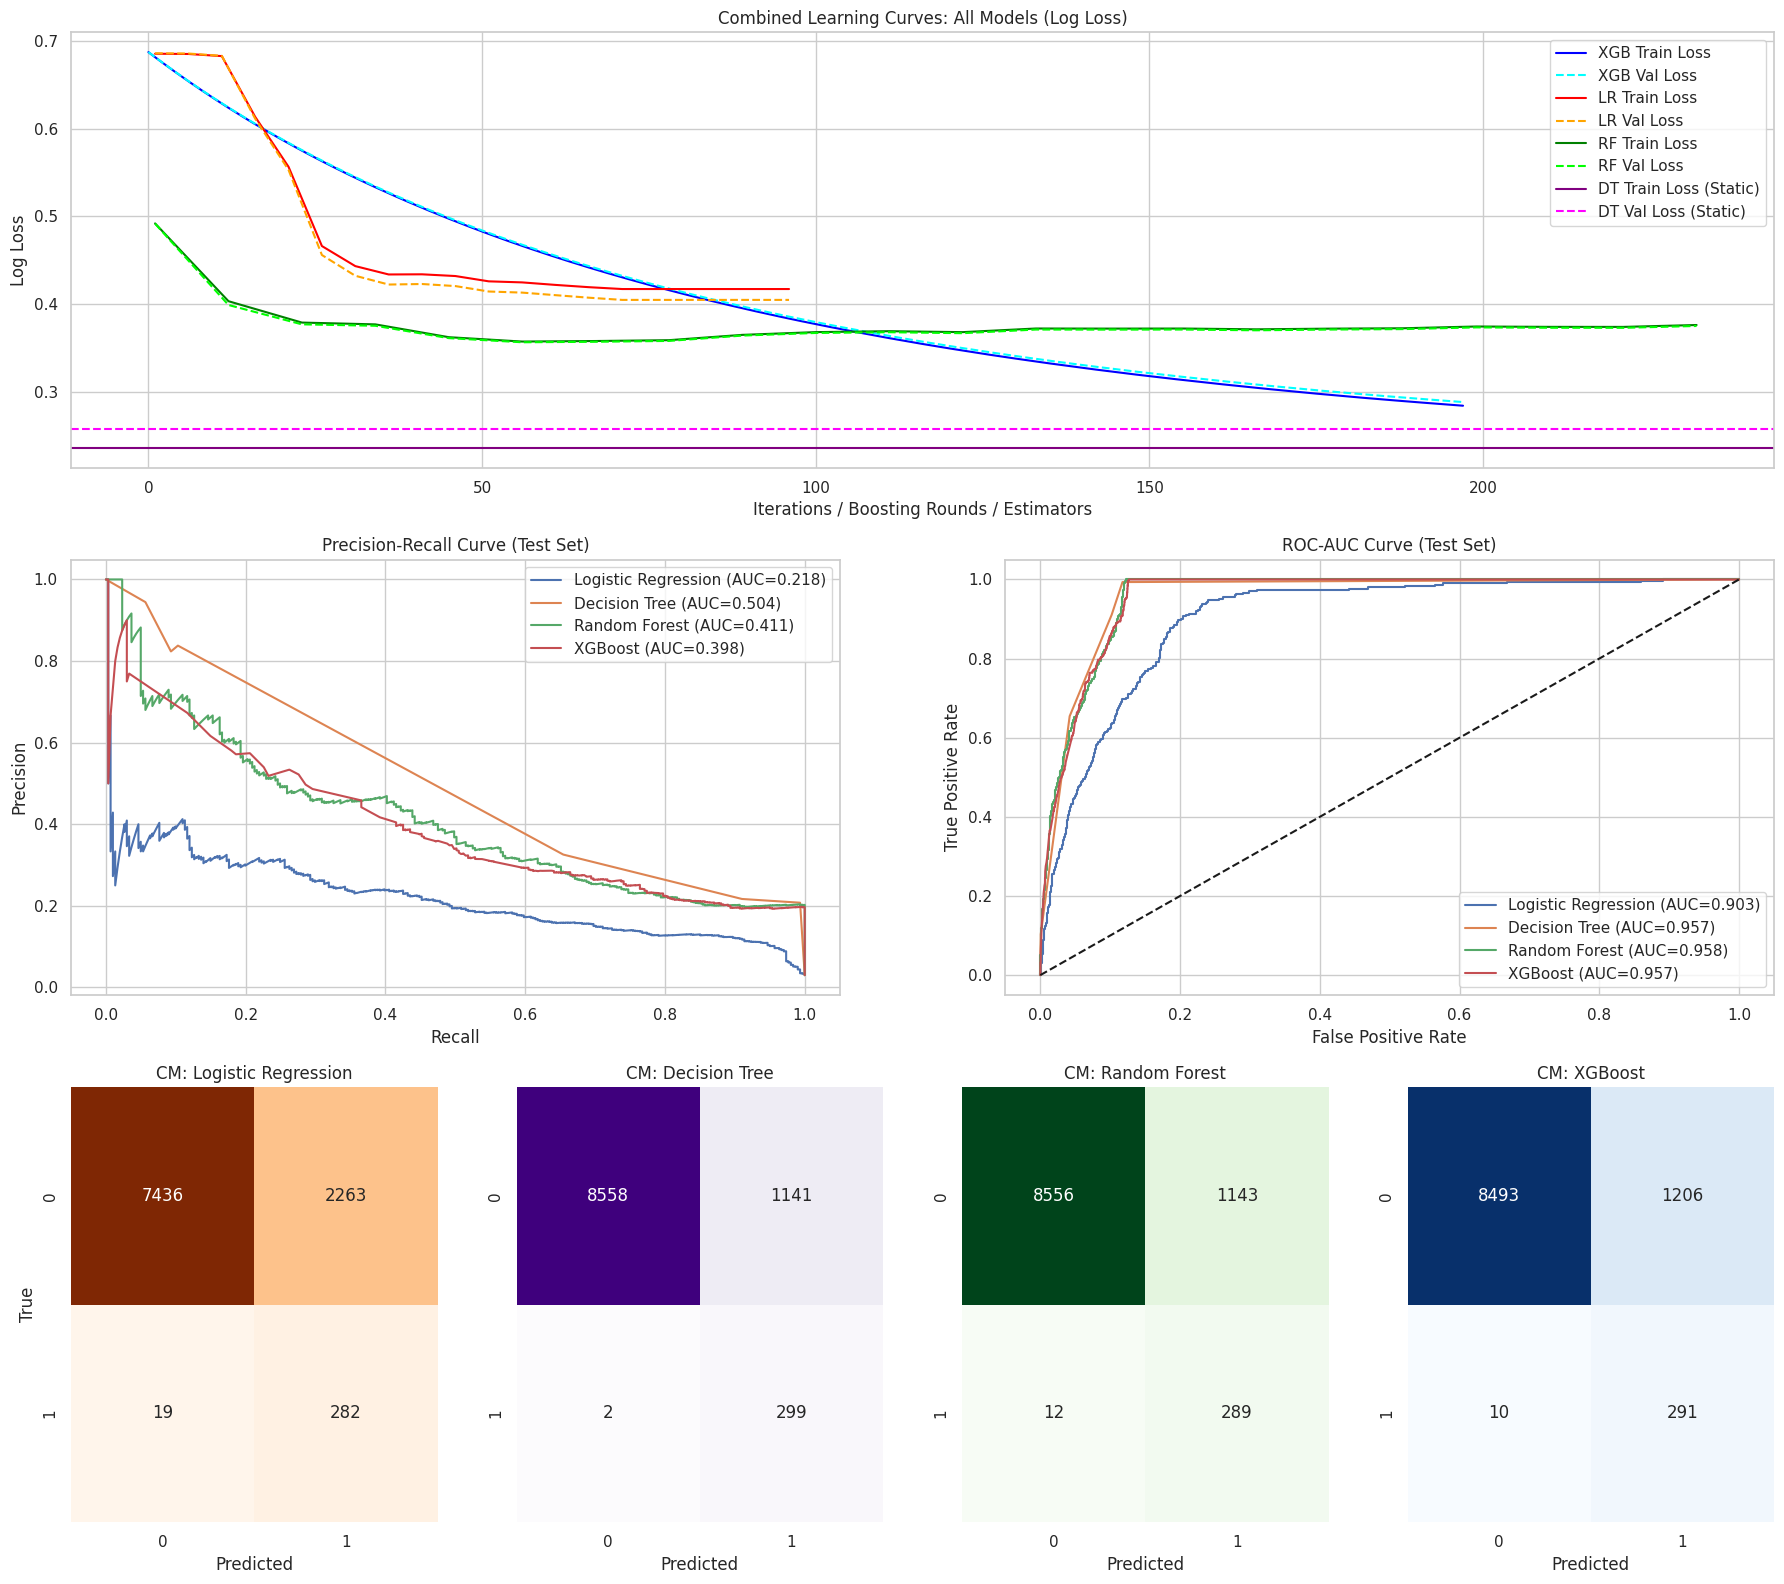

In [6]:
accuracy_based_baselines(c1_train_data, c1_val_data, c1_test_data)

#### Insurance cost based models

In [7]:
import optuna
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, precision_score,
                             recall_score, f1_score, roc_auc_score)

def cost_optimized_baselines(train_data, val_data, test_data):
    # --- Configuration ---
    TARGET = 'fraud_label'
    SUM_INSURED = 'sum_insured'

    COST_TP = 100  # Human investigation cost for caught fraud
    COST_FP = 150  # Wasted investigation + reputation damage
    COST_TN = 0    # No action, no cost

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    warnings.filterwarnings("ignore", category=UserWarning)

    # --- Data Preparation ---
    y_train, si_train = train_data[TARGET].values, train_data[SUM_INSURED].values
    y_val, si_val     = val_data[TARGET].values, val_data[SUM_INSURED].values
    y_test, si_test   = test_data[TARGET].values, test_data[SUM_INSURED].values

    X_train = train_data.drop(columns=[TARGET, SUM_INSURED])
    X_val   = val_data.drop(columns=[TARGET, SUM_INSURED])
    X_test  = test_data.drop(columns=[TARGET, SUM_INSURED])

    # --- Core Business Logic ---
    def compute_business_cost(y_true, y_pred_proba, sum_insured_vals, threshold):
        y_pred = (y_pred_proba >= threshold).astype(int)
        cost = np.zeros(len(y_true), dtype=np.float64)

        tp_mask = (y_pred == 1) & (y_true == 1)
        cost[tp_mask] = COST_TP

        fp_mask = (y_pred == 1) & (y_true == 0)
        cost[fp_mask] = COST_FP

        fn_mask = (y_pred == 0) & (y_true == 1)
        cost[fn_mask] = 0.9 * np.maximum(sum_insured_vals[fn_mask], 0)

        return float(np.sum(cost))

    def make_sample_weights(y_true, sum_insured_vals):
        weights = np.where(
            y_true == 1,
            0.9 * np.maximum(sum_insured_vals, 0),
            COST_FP
        ).astype(np.float64)

        weights = np.maximum(weights, 1e-6)
        return weights / weights.mean()

    sw_train = make_sample_weights(y_train, si_train)

    # --- Logistic Regression Tuning ---
    def objective_lr(trial):
        C = trial.suggest_float('C', 1e-4, 10.0, log=True)
        solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear'])
        threshold = trial.suggest_float('threshold', 0.05, 0.95)

        model = LogisticRegression(C=C, solver=solver, max_iter=1000, random_state=42)
        model.fit(X_train, y_train, sample_weight=sw_train)

        probs = model.predict_proba(X_val)[:, 1]
        cost = compute_business_cost(y_val, probs, si_val, threshold)
        return cost / len(y_val)

    study_lr = optuna.create_study(direction='minimize')
    study_lr.optimize(objective_lr, n_trials=15)
    best_lr_params = study_lr.best_params.copy()
    lr_opt_thresh = best_lr_params.pop('threshold')

    # --- Decision Tree Tuning ---
    def objective_dt(trial):
        max_depth = trial.suggest_int('max_depth', 3, 15)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        threshold = trial.suggest_float('threshold', 0.05, 0.95)

        model = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)
        model.fit(X_train, y_train, sample_weight=sw_train)

        probs = model.predict_proba(X_val)[:, 1]
        cost = compute_business_cost(y_val, probs, si_val, threshold)
        return cost / len(y_val)

    study_dt = optuna.create_study(direction='minimize')
    study_dt.optimize(objective_dt, n_trials=15)
    best_dt_params = study_dt.best_params.copy()
    dt_opt_thresh = best_dt_params.pop('threshold')

    # --- Random Forest Tuning ---
    def objective_rf(trial):
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 15)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        threshold = trial.suggest_float('threshold', 0.05, 0.95)

        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,
                                       min_samples_split=min_samples_split, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train, sample_weight=sw_train)

        probs = model.predict_proba(X_val)[:, 1]
        cost = compute_business_cost(y_val, probs, si_val, threshold)
        return cost / len(y_val)

    study_rf = optuna.create_study(direction='minimize')
    study_rf.optimize(objective_rf, n_trials=15)
    best_rf_params = study_rf.best_params.copy()
    rf_opt_thresh = best_rf_params.pop('threshold')

    # --- XGBoost Tuning ---
    def objective_xgb(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'random_state': 42,
            'eval_metric': 'logloss'
        }
        threshold = trial.suggest_float('threshold', 0.05, 0.95)

        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, sample_weight=sw_train, verbose=False)

        probs = model.predict_proba(X_val)[:, 1]
        cost = compute_business_cost(y_val, probs, si_val, threshold)
        return cost / len(y_val)

    study_xgb = optuna.create_study(direction='minimize')
    study_xgb.optimize(objective_xgb, n_trials=15)
    best_xgb_params = study_xgb.best_params.copy()
    xgb_opt_thresh = best_xgb_params.pop('threshold')


    # --- Train Final Models & Evaluate ---

    # 1. Final Logistic Regression
    final_lr = LogisticRegression(**best_lr_params, max_iter=1000, random_state=42)
    final_lr.fit(X_train, y_train, sample_weight=sw_train)
    lr_test_probs = final_lr.predict_proba(X_test)[:, 1]
    lr_test_preds = (lr_test_probs >= lr_opt_thresh).astype(int)
    lr_test_cost = compute_business_cost(y_test, lr_test_probs, si_test, lr_opt_thresh)

    # 2. Final Decision Tree
    final_dt = DecisionTreeClassifier(**best_dt_params, random_state=42)
    final_dt.fit(X_train, y_train, sample_weight=sw_train)
    dt_test_probs = final_dt.predict_proba(X_test)[:, 1]
    dt_test_preds = (dt_test_probs >= dt_opt_thresh).astype(int)
    dt_test_cost = compute_business_cost(y_test, dt_test_probs, si_test, dt_opt_thresh)

    # 3. Final Random Forest
    final_rf = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
    final_rf.fit(X_train, y_train, sample_weight=sw_train)
    rf_test_probs = final_rf.predict_proba(X_test)[:, 1]
    rf_test_preds = (rf_test_probs >= rf_opt_thresh).astype(int)
    rf_test_cost = compute_business_cost(y_test, rf_test_probs, si_test, rf_opt_thresh)

    # 4. Final XGBoost
    final_xgb = xgb.XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss')
    final_xgb.fit(X_train, y_train, sample_weight=sw_train, verbose=False)
    xgb_test_probs = final_xgb.predict_proba(X_test)[:, 1]
    xgb_test_preds = (xgb_test_probs >= xgb_opt_thresh).astype(int)
    xgb_test_cost = compute_business_cost(y_test, xgb_test_probs, si_test, xgb_opt_thresh)

    # --- Calculate Traditional Metrics ---
    def get_metrics_dict(preds, probs):
        return {
            'Precision': precision_score(y_test, preds, zero_division=0),
            'Recall': recall_score(y_test, preds, zero_division=0),
            'F1-Score': f1_score(y_test, preds, zero_division=0),
            'ROC-AUC': roc_auc_score(y_test, probs)
        }

    metrics_data = {
        'Logistic Regression': get_metrics_dict(lr_test_preds, lr_test_probs),
        'Decision Tree': get_metrics_dict(dt_test_preds, dt_test_probs),
        'Random Forest': get_metrics_dict(rf_test_preds, rf_test_probs),
        'XGBoost': get_metrics_dict(xgb_test_preds, xgb_test_probs)
    }

    # --- Compile Final Financial Results ---
    def create_result_row(model_name, thresh, cost, probs, preds):
        return {
            'Model': model_name,
            'Opt_Threshold': thresh,
            'Cost / Row': cost / len(y_test),
            'Total Cost (Test)': cost,
            **metrics_data[model_name]
        }

    results_df = pd.DataFrame([
        create_result_row('Logistic Regression', lr_opt_thresh, lr_test_cost, lr_test_probs, lr_test_preds),
        create_result_row('Decision Tree', dt_opt_thresh, dt_test_cost, dt_test_probs, dt_test_preds),
        create_result_row('Random Forest', rf_opt_thresh, rf_test_cost, rf_test_probs, rf_test_preds),
        create_result_row('XGBoost', xgb_opt_thresh, xgb_test_cost, xgb_test_probs, xgb_test_preds)
    ])

    print("\n--- Final Test Set Financial & Statistical Performance ---")
    try:
        display(results_df)
    except NameError:
        print(results_df.to_string())

    # --- Visualizations ---
    fig = plt.figure(figsize=(18, 16))
    sns.set_theme(style="whitegrid")

    # 1. Cost vs Threshold Sweep (Top Row)
    ax1 = plt.subplot(3, 1, 1)
    thresholds_plot = np.linspace(0.01, 0.99, 99)

    lr_costs = [compute_business_cost(y_test, lr_test_probs, si_test, t) for t in thresholds_plot]
    dt_costs = [compute_business_cost(y_test, dt_test_probs, si_test, t) for t in thresholds_plot]
    rf_costs = [compute_business_cost(y_test, rf_test_probs, si_test, t) for t in thresholds_plot]
    xgb_costs = [compute_business_cost(y_test, xgb_test_probs, si_test, t) for t in thresholds_plot]

    ax1.plot(thresholds_plot, lr_costs, label='Logistic Regression Cost', color='orange', linewidth=2)
    ax1.plot(thresholds_plot, dt_costs, label='Decision Tree Cost', color='purple', linewidth=2)
    ax1.plot(thresholds_plot, rf_costs, label='Random Forest Cost', color='green', linewidth=2)
    ax1.plot(thresholds_plot, xgb_costs, label='XGBoost Cost', color='blue', linewidth=2)

    ax1.axvline(lr_opt_thresh, color='orange', linestyle='--', alpha=0.7, label=f'LR Thresh: {lr_opt_thresh:.2f}')
    ax1.axvline(dt_opt_thresh, color='purple', linestyle='--', alpha=0.7, label=f'DT Thresh: {dt_opt_thresh:.2f}')
    ax1.axvline(rf_opt_thresh, color='green', linestyle='--', alpha=0.7, label=f'RF Thresh: {rf_opt_thresh:.2f}')
    ax1.axvline(xgb_opt_thresh, color='blue', linestyle='--', alpha=0.7, label=f'XGB Thresh: {xgb_opt_thresh:.2f}')

    ax1.scatter([lr_opt_thresh, dt_opt_thresh, rf_opt_thresh, xgb_opt_thresh],
                [lr_test_cost, dt_test_cost, rf_test_cost, xgb_test_cost],
                color=['orange', 'purple', 'green', 'blue'], s=100, zorder=5)

    ax1.set_title('Financial Impact: Total Portfolio Cost vs. Classification Threshold', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Probability Threshold')
    ax1.set_ylabel('Total Cost Incurred ($)')
    ax1.legend(loc='upper right', ncol=2)

    # 2. Confusion Matrices (Middle Row - 4 across)
    model_configs = [
        (lr_test_preds, lr_opt_thresh, 'Oranges', 'LR'),
        (dt_test_preds, dt_opt_thresh, 'Purples', 'DT'),
        (rf_test_preds, rf_opt_thresh, 'Greens', 'RF'),
        (xgb_test_preds, xgb_opt_thresh, 'Blues', 'XGBoost')
    ]

    for i, (preds, thresh, cmap, name) in enumerate(model_configs):
        ax = plt.subplot(3, 4, 5 + i)
        sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap=cmap, ax=ax, cbar=False)
        ax.set_title(f'Cost-Weighted {name}\n(Thresh: {thresh:.2f})')
        ax.set_xlabel('Predicted')
        if i == 0:
            ax.set_ylabel('True')

    # 3. Traditional Metrics Comparison (Bottom Row)
    ax3 = plt.subplot(3, 1, 3)
    metrics_labels = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']

    lr_scores = [metrics_data['Logistic Regression'][m] for m in metrics_labels]
    dt_scores = [metrics_data['Decision Tree'][m] for m in metrics_labels]
    rf_scores = [metrics_data['Random Forest'][m] for m in metrics_labels]
    xgb_scores = [metrics_data['XGBoost'][m] for m in metrics_labels]

    x = np.arange(len(metrics_labels))
    width = 0.2  # Thinner bars to fit 4 groups

    bars1 = ax3.bar(x - 1.5*width, lr_scores, width, label='Logistic Regression', color='orange', alpha=0.8)
    bars2 = ax3.bar(x - 0.5*width, dt_scores, width, label='Decision Tree', color='purple', alpha=0.8)
    bars3 = ax3.bar(x + 0.5*width, rf_scores, width, label='Random Forest', color='green', alpha=0.8)
    bars4 = ax3.bar(x + 1.5*width, xgb_scores, width, label='XGBoost', color='blue', alpha=0.8)

    ax3.set_title('Traditional Metrics Comparison (Calculated at Optimal Threshold)', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Score')
    ax3.set_xticks(x)
    ax3.set_xticklabels(metrics_labels)
    ax3.set_ylim(0, 1.15)
    ax3.legend(ncol=4, loc='upper center')

    # Add text labels above bars
    for bars in [bars1, bars2, bars3, bars4]:
        for bar in bars:
            yval = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


--- Final Test Set Financial & Statistical Performance ---


,Model,Opt_Threshold,Cost / Row,Total Cost (Test),Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.838510,148.49500,1484950.0,0.030100,1.000000,0.058441,0.505815
1,Decision Tree,0.346339,70.58840,705884.0,0.205781,0.993355,0.340935,0.940353
2,Random Forest,0.297031,104.79583,1047958.3,0.181486,0.990033,0.306742,0.945694
3,XGBoost,0.939554,173.04178,1730417.8,0.208924,0.980066,0.344425,0.964505


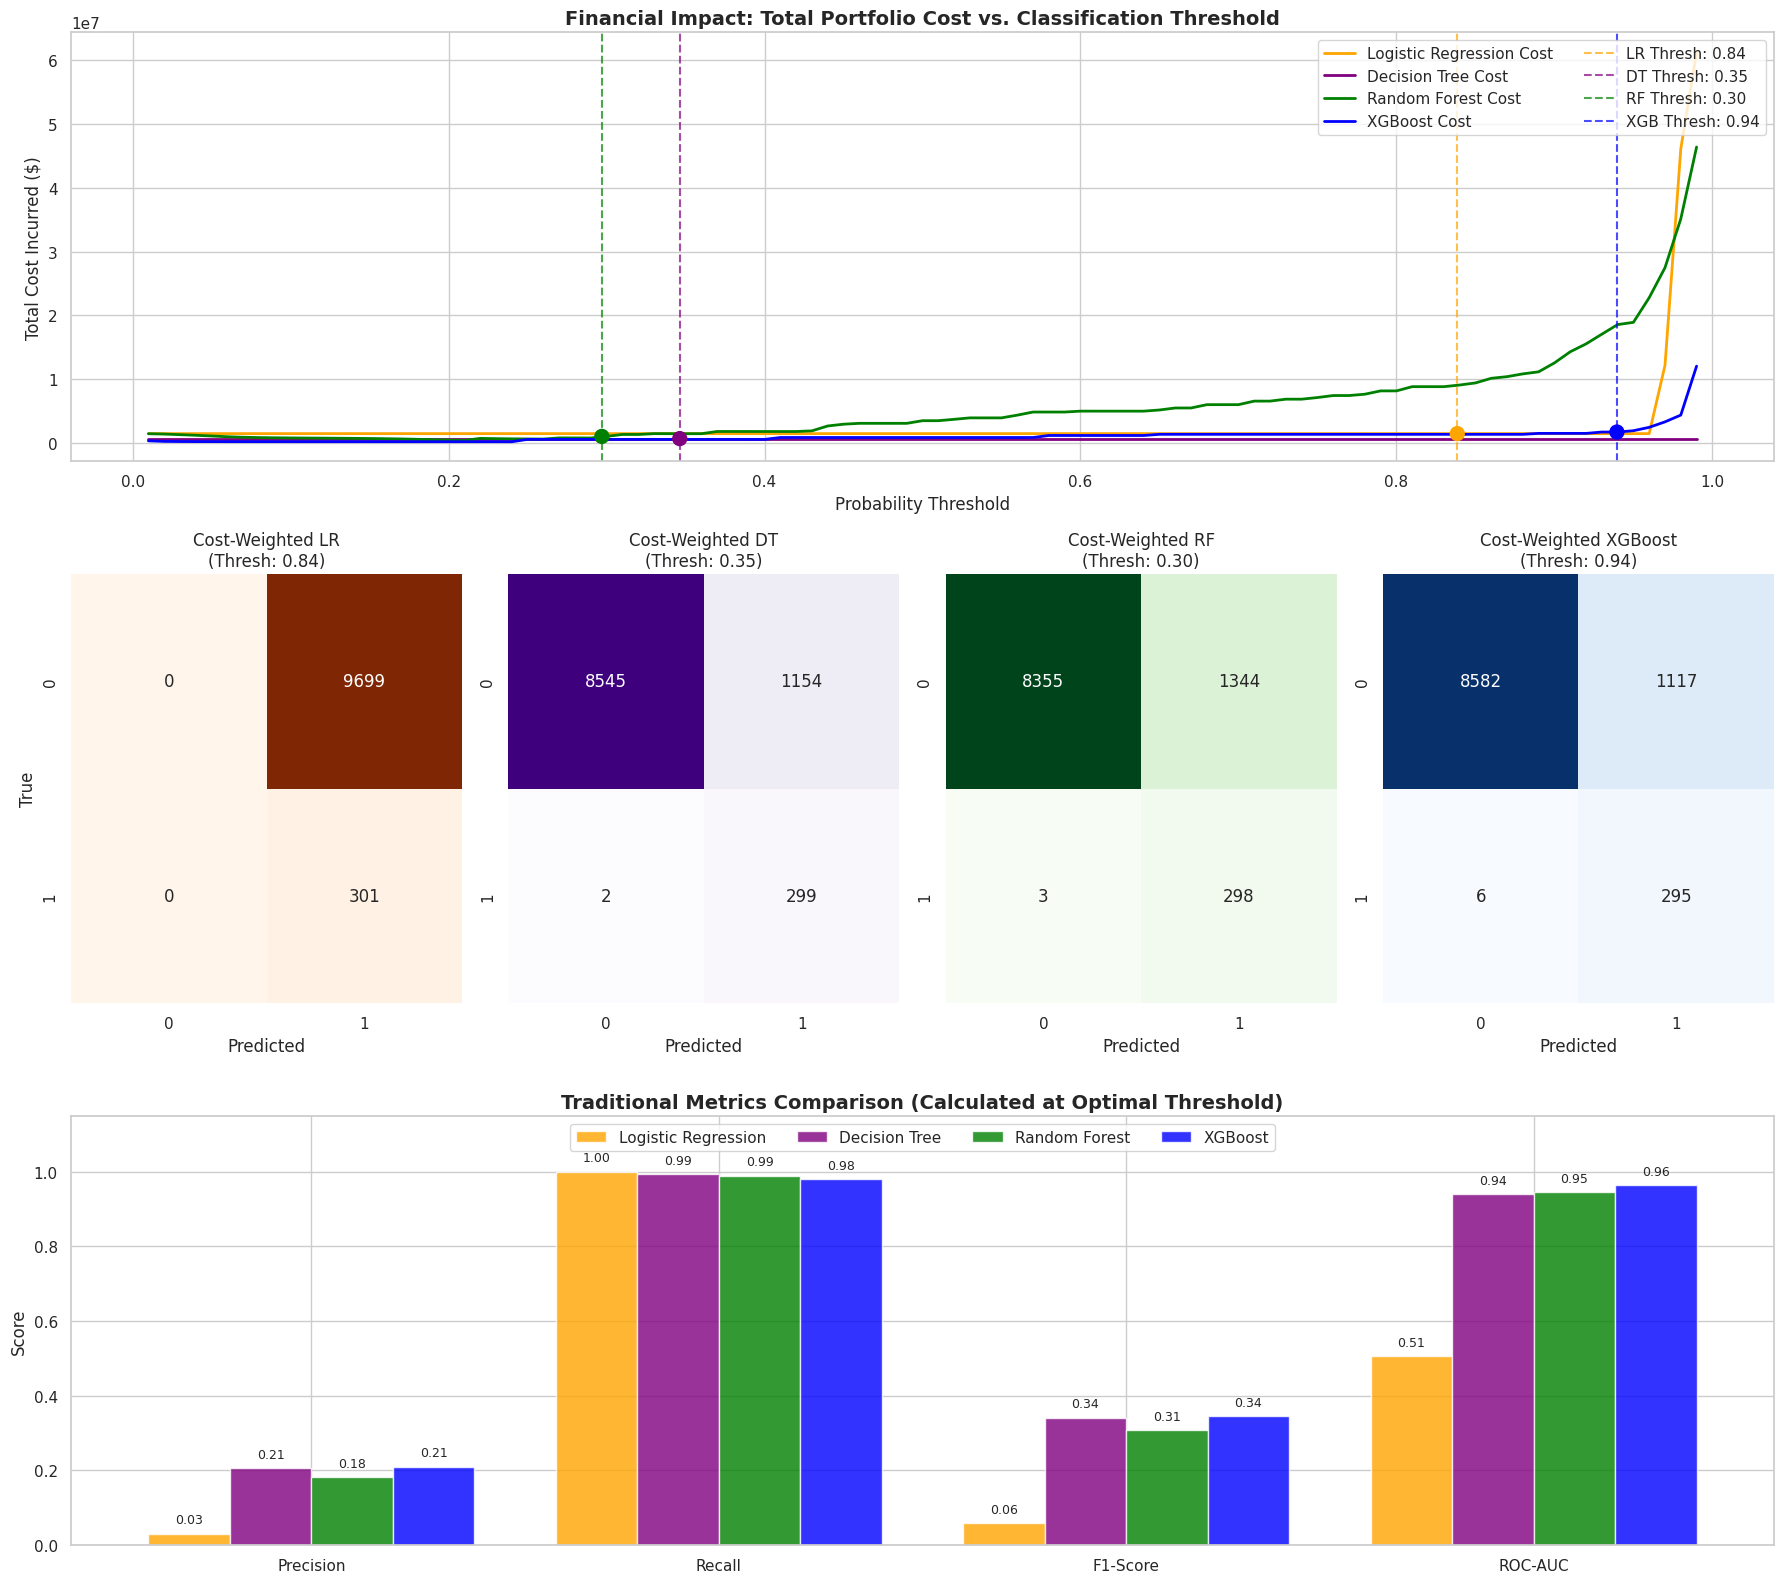

In [8]:
cost_optimized_baselines(c1_train_data, c1_val_data, c1_test_data)

### Case 2: Train (45k) and val (20k) from labeled, while Test (10k) from unlabled set

In [9]:
c2_train_data, c2_val_data = train_test_split(df_labeled, test_size=20000, random_state=42, stratify=df_labeled['fraud_label'])
c2_test_data, df_remaining_unlabeled = train_test_split(df_unlabeled, train_size=10000, stratify=df_unlabeled['fraud_label'], random_state=42)

#### Accuracy based models

Best LR Params: {'C': 0.660605378938242, 'solver': 'liblinear'}
Best DT Params: {'max_depth': 6, 'min_samples_split': 15}
Best RF Params: {'n_estimators': 75, 'max_depth': 5, 'min_samples_split': 8}
Best XGB Params: {'n_estimators': 115, 'max_depth': 3, 'learning_rate': 0.06181665129888664, 'subsample': 0.7577715047338891}

--- Final Test Set Performance ---


,Model,ROC-AUC,F1-Score,Precision,Recall
0,Logistic Regression,0.897624,0.194435,0.108704,0.920000
1,Decision Tree,0.960261,0.340909,0.205479,1.000000
2,Random Forest,0.951370,0.324719,0.195270,0.963333
3,XGBoost,0.956589,0.321951,0.192233,0.990000


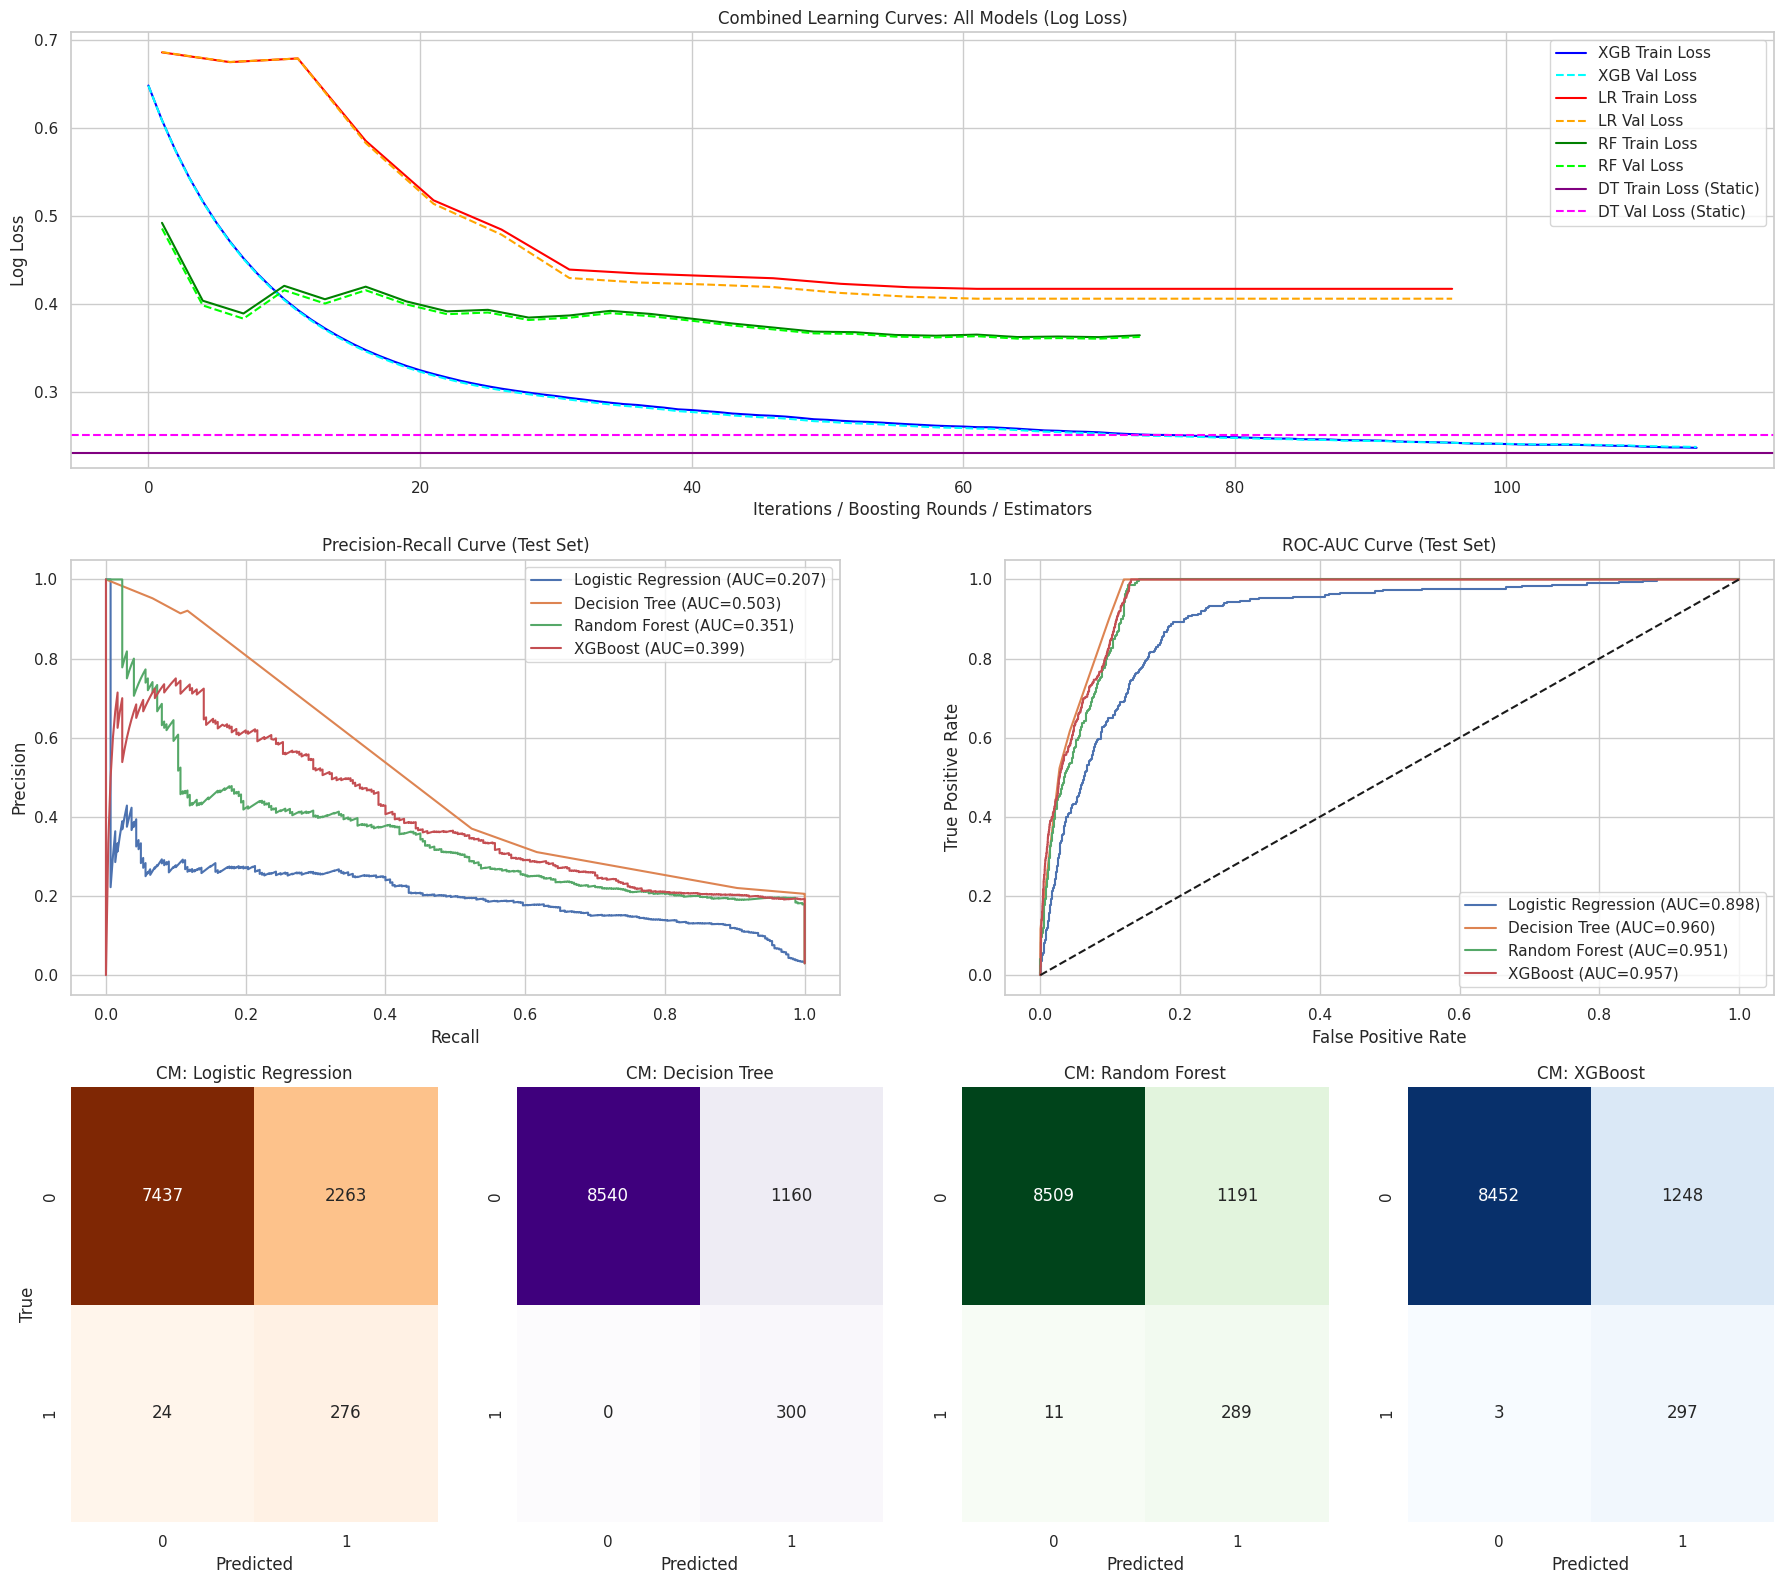

In [10]:
accuracy_based_baselines(c2_train_data, c2_val_data, c2_test_data)

#### Insurance cost based models


--- Final Test Set Financial & Statistical Performance ---


,Model,Opt_Threshold,Cost / Row,Total Cost (Test),Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.310748,148.500,1485000.0,0.030000,1.0,0.058252,0.506235
1,Decision Tree,0.675586,42.750,427500.0,0.101695,1.0,0.184615,0.935939
2,Random Forest,0.343953,47.400,474000.0,0.092025,1.0,0.168539,0.943663
3,XGBoost,0.428643,22.245,222450.0,0.189514,1.0,0.318640,0.954396


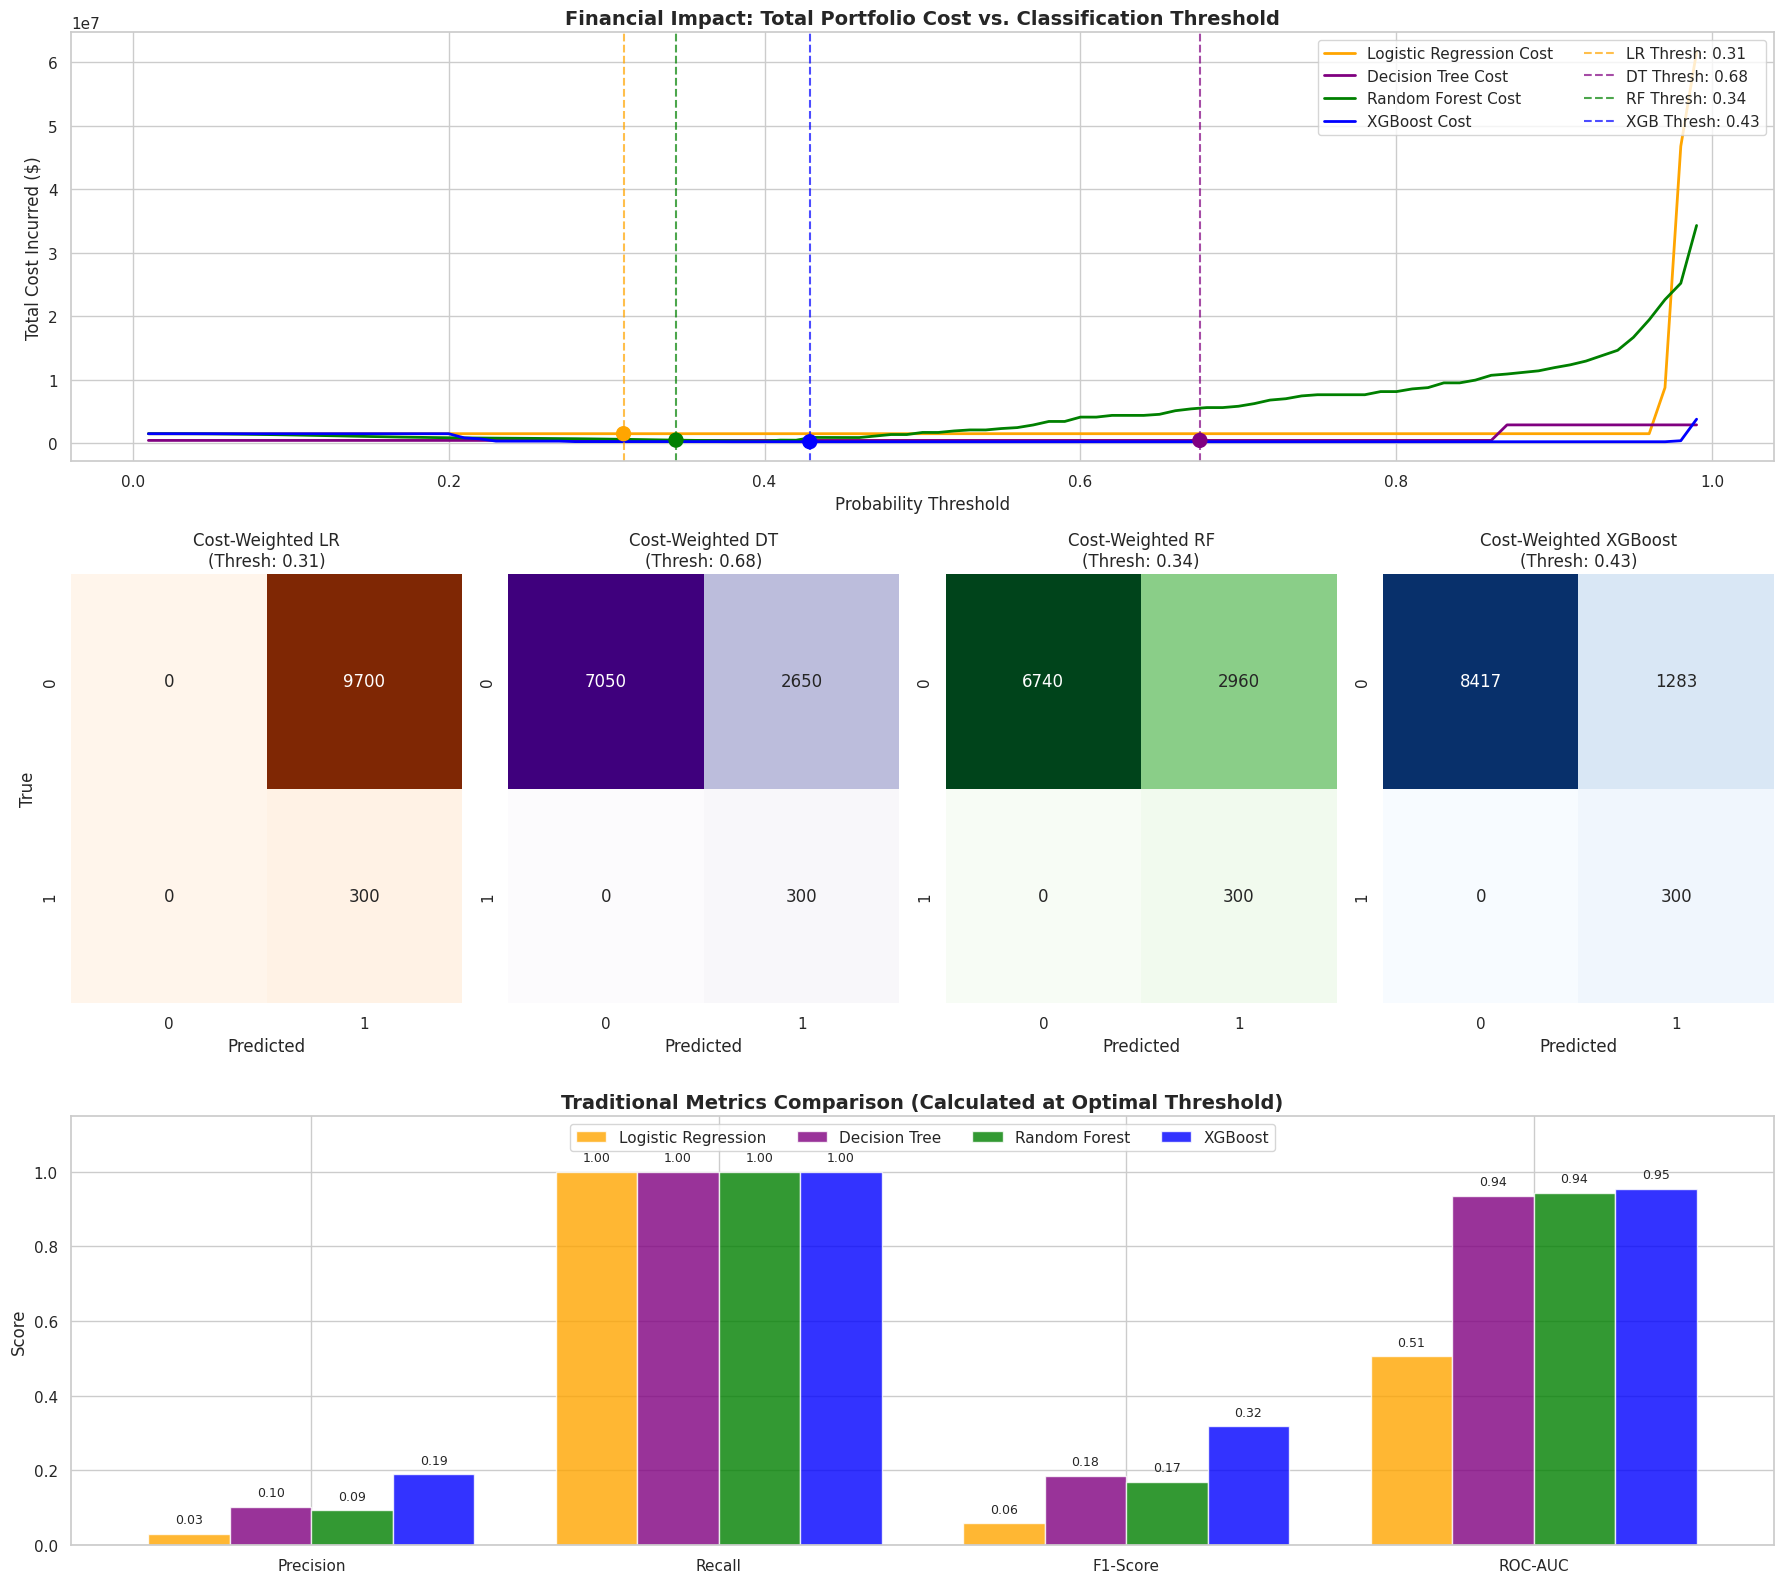

In [11]:
cost_optimized_baselines(c2_train_data, c2_val_data, c2_test_data)

## AL begins

'-1' is kept as it is when doing the cost-weighted uncertainty by the model, for querying purpose.

Note: Its NOT replaced by any NaN or random value.

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║                    USER CONFIG                           ║
# ╚══════════════════════════════════════════════════════════╝

# ── File paths ───────────────────────────────────────────────
BEST_PARAMS_JSON   = "best_params.json"

# ── Column names (must match both CSVs) ──────────────────────
TARGET_COL         = "fraud_label"         # label column (0 / 1) in labeled CSV
SUM_INSURED_COL    = "sum_insured"         # insured amount column

# ── Active Learning settings ─────────────────────────────────
N_AL_LOOPS         = 10                   # number of AL iterations to run
N_QUERY_PER_LOOP   = 100                  # uncertain points to query each loop
N_SUBSAMPLE        = 2000   # unlabeled rows to draw each AL loop (must be ≥ N_QUERY_PER_LOOP)
EARLY_STOPPING = 50                       # stop if business cost on val doesn't improve for this many rounds

# ── Output ───────────────────────────────────────────────────
FINAL_MODEL_PATH     = "al_final_model.json"  # final retrained XGBoost model
FINAL_NON_SEQUENTIAL_MODEL_PATH = "nonsequential_final_model.json"

# ── Business cost params (must match what the tuner used) ────
COST_TP             = 100              # model says fraud (1), actually fraud (1)     → investigation cost
COST_FP             = 150              # model says fraud (1), actually not fraud (0) → false alarm cost + reputation damage
COST_TN             = 0               # model says not fraud (0), actually not fraud  → no cost (fixed)
# COST_FN             = 0.9 * sum_insured  per row (missed fraud = pay out 90% of claim)

In [ ]:
import json
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

warnings.filterwarnings("ignore")

def compute_business_cost(y_true, y_pred_proba, sum_insured_vals,
                           threshold=0.5, cost_tp=COST_TP, cost_fp=COST_FP):
    """Identical cost function from optuna — lower is better."""
    y_pred             = (y_pred_proba >= threshold).astype(int)
    cost               = np.zeros(len(y_true), dtype=np.float64)
    cost[(y_pred==1) & (y_true==1)] = cost_tp
    cost[(y_pred==1) & (y_true==0)] = cost_fp
    cost[(y_pred==0) & (y_true==1)] = 0.9 * sum_insured_vals[(y_pred==0) & (y_true==1)]
    return float(np.sum(cost))


def make_sample_weights(y_train_fold, si_train_fold):
    """
    Weight each training sample by its expected cost contribution.
    Fraud samples  → weighted by the payout we'd miss (0.9 * sum_insured).
    Non-fraud      → weighted by the false-alarm cost (COST_FP).
    scale_pos_weight is NOT used alongside these weights to avoid double-counting.
    """
    weights = np.where(
        y_train_fold == 1,
        0.9 * np.maximum(si_train_fold, 0),
        COST_FP
    ).astype(np.float64)
    weights = np.maximum(weights, 1e-6)   # XGBoost requires strictly positive weights
    weights = weights / weights.mean()    # normalise so mean weight ≈ 1
    return weights


def business_cost_eval(y_proba, dtrain, sum_insured_vals, threshold):
    """
    Custom eval metric for xgb.train.
    Called every boosting round so early stopping is driven by business cost,
    not logloss.
    y_proba is already a probability because objective='binary:logistic'.
    """
    y_true     = dtrain.get_label()
    cost       = compute_business_cost(y_true, y_proba, sum_insured_vals,
                                        threshold=threshold)
    normalised = cost / max(len(y_true), 1)   # per-row cost for comparability
    return "business_cost", normalised


def load_params_from_json(json_path):
    """
    Loads best_params.json written by optuna.
    Returns (xgb_params_dict, n_estimators, threshold).
    Strips 'threshold', 'n_estimators', and '_meta' — these are handled
    separately by xgb.train (num_boost_round) and the AL loop.
    """
    with open(json_path) as f:
        raw = json.load(f)

    params        = {k: v for k, v in raw.items() if not k.startswith("_")}
    threshold     = params.pop("threshold", 0.5)
    n_estimators  = params.pop("n_estimators", 300)   # used as num_boost_round

    return params, n_estimators, threshold

def build_and_train_model(params, n_estimators, threshold, X_train, y_train, si_train):
    """
    Trains XGBoost via xgb.train (identical pattern to optuna).
    - sample_weight encodes the business cost asymmetry into every gradient step
    - custom_metric (business_cost_eval) drives early stopping — NOT logloss
    Returns a raw xgb.Booster.
    """
    sw     = make_sample_weights(y_train, si_train)
    dtrain = xgb.DMatrix(X_train, label=y_train, weight=sw)
    dval   = xgb.DMatrix(X_train, label=y_train)   # use train as val proxy when no holdout

    # Bind threshold into the eval closure (mirrors the fold_eval pattern in the tuner)
    def _cost_eval(y_proba, dtrain_inner, _si=si_train, _th=threshold):
        return business_cost_eval(y_proba, dtrain_inner, _si, _th)

    xgb_train_params = {
        "objective"   : "binary:logistic",
        "tree_method" : "hist",
        "seed"        : 42,
        "verbosity"   : 0,
        # "nthread"     : 1,
        **params,
    }

    booster = xgb.train(
        xgb_train_params,
        dtrain,
        num_boost_round       = n_estimators,
        evals                 = [(dval, "train")],
        custom_metric         = _cost_eval,        # early stopping watches business cost
        early_stopping_rounds = EARLY_STOPPING,
        maximize              = False,
        verbose_eval          = False,
    )
    return booster

print("✅ Helpers defined.")

✅ Helpers defined.


In [ ]:
# ── Load tuned hyper-parameters ──────────────────────────────
xgb_params, N_ESTIMATORS, THRESHOLD = load_params_from_json(BEST_PARAMS_JSON)

print(f"[BASELINE] Loaded params from '{BEST_PARAMS_JSON}'")
print(f"  Threshold : {THRESHOLD}")
print(f"  XGB params:")
for k, v in xgb_params.items():
    print(f"    {k:<25} = {v}")

# ── Load labeled training pool ────────────────────────────────
X_pool_train  = c1_train_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_pool_train  = c1_train_data[TARGET_COL].values.astype(np.int32)
si_pool_train = c1_train_data[SUM_INSURED_COL].values.astype(np.float64)

print(f"fraud={y_pool_train.sum():,} ({100*y_pool_train.mean():.1f}%)")

# ── Train baseline model on full labeled pool ─────────────────
print("\n[BASELINE] Training baseline XGBoost on labeled pool …")
baseline_model = build_and_train_model(xgb_params, N_ESTIMATORS, THRESHOLD, X_pool_train, y_pool_train, si_pool_train)


X_pool_test  = c1_test_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_pool_test  = c1_test_data[TARGET_COL].values.astype(np.int32)
si_pool_test = c1_test_data[SUM_INSURED_COL].values.astype(np.float64)


baseline_proba = baseline_model.predict(xgb.DMatrix(X_pool_test),
                     iteration_range=(0, baseline_model.best_iteration + 1))
baseline_cost  = compute_business_cost(y_pool_test, baseline_proba, si_pool_test, THRESHOLD)
baseline_auc   = roc_auc_score(y_pool_test, baseline_proba)

print(f"  ✅ Baseline trained.")
print(f"  Baseline AUC (train)          : {baseline_auc:.4f}")
print(f"  Baseline business cost (train): {baseline_cost:,.0f}")
print(f"  (Train-set scores are optimistic — used only as AL progress reference)")
print(f'  Number of rows in LABELED_CSV = {len(df_labeled)}')

[BASELINE] Loaded params from 'best_params.json'
  Threshold : 0.10854643368675157
  XGB params:
    max_depth                 = 5
    min_child_weight          = 4
    gamma                     = 0.45606998421703593
    learning_rate             = 0.12448918446337819
    subsample                 = 0.5998368910791798
    colsample_bytree          = 0.708540663048167
    colsample_bylevel         = 0.7554487413172255
    reg_alpha                 = 2.4298880728901692e-08
    reg_lambda                = 0.0019275890163896973
fraud=1,351 (3.0%)

[BASELINE] Training baseline XGBoost on labeled pool …
  ✅ Baseline trained.
  Baseline AUC (train)          : 0.9583
  Baseline business cost (train): 224,350
  (Train-set scores are optimistic — used only as AL progress reference)
  Number of rows in LABELED_CSV = 65000


In [ ]:
# ── Load tuned hyper-parameters ──────────────────────────────
xgb_params, N_ESTIMATORS, THRESHOLD = load_params_from_json(BEST_PARAMS_JSON)

print(f"[BASELINE] Loaded params from '{BEST_PARAMS_JSON}'")
print(f"  Threshold : {THRESHOLD}")
print(f"  XGB params:")
for k, v in xgb_params.items():
    print(f"    {k:<25} = {v}")

# ── Load labeled training pool ────────────────────────────────
X_pool_train  = c1_train_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_pool_train  = c1_train_data[TARGET_COL].values.astype(np.int32)
si_pool_train = c1_train_data[SUM_INSURED_COL].values.astype(np.float64)

print(f"fraud={y_pool_train.sum():,} ({100*y_pool_train.mean():.1f}%)")

# ── Train baseline model on full labeled pool ─────────────────
print("\n[BASELINE] Training baseline XGBoost on labeled pool …")
baseline_model = build_and_train_model(xgb_params, N_ESTIMATORS, THRESHOLD, X_pool_train, y_pool_train, si_pool_train)


X_pool_test  = c2_test_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_pool_test  = c2_test_data[TARGET_COL].values.astype(np.int32)
si_pool_test = c2_test_data[SUM_INSURED_COL].values.astype(np.float64)


baseline_proba = baseline_model.predict(xgb.DMatrix(X_pool_test),
                     iteration_range=(0, baseline_model.best_iteration + 1))
baseline_cost  = compute_business_cost(y_pool_test, baseline_proba, si_pool_test, THRESHOLD)
baseline_auc   = roc_auc_score(y_pool_test, baseline_proba)

print(f"  ✅ Baseline trained.")
print(f"  Baseline AUC (test)          : {baseline_auc:.4f}")
print(f"  Baseline business cost (test): {baseline_cost:,.0f}")
print(f"  (Train-set scores are optimistic — used only as AL progress reference)")
print(f'  Number of rows in LABELED_CSV = {len(df_labeled)}')

[BASELINE] Loaded params from 'best_params.json'
  Threshold : 0.10854643368675157
  XGB params:
    max_depth                 = 5
    min_child_weight          = 4
    gamma                     = 0.45606998421703593
    learning_rate             = 0.12448918446337819
    subsample                 = 0.5998368910791798
    colsample_bytree          = 0.708540663048167
    colsample_bylevel         = 0.7554487413172255
    reg_alpha                 = 2.4298880728901692e-08
    reg_lambda                = 0.0019275890163896973
fraud=1,351 (3.0%)

[BASELINE] Training baseline XGBoost on labeled pool …
  ✅ Baseline trained.
  Baseline AUC (test)          : 0.9533
  Baseline business cost (test): 232,950
  (Train-set scores are optimistic — used only as AL progress reference)
  Number of rows in LABELED_CSV = 65000


In [ ]:
# ── Working copies (mutated each loop) ───────────────────────
current_model   = baseline_model           # starts as baseline (xgb.Booster), updated each loop
X_train_current = c1_train_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])            # grows as new labels arrive
y_train_current = c1_train_data[TARGET_COL].values.astype(np.int32)
si_train_current = c1_train_data[SUM_INSURED_COL].values.astype(np.float64)

len(y_train_current)

45000

In [ ]:
# ── Pre-shuffle unlabeled pool once → guarantees non-overlapping N_SUBSAMPLE
#    chunks across all AL loops without any set bookkeeping.
assert N_SUBSAMPLE >= N_QUERY_PER_LOOP, \
    f"N_SUBSAMPLE ({N_SUBSAMPLE}) must be ≥ N_QUERY_PER_LOOP ({N_QUERY_PER_LOOP})"
assert N_SUBSAMPLE * N_AL_LOOPS <= len(df_remaining_unlabeled), \
    (f"Not enough unlabeled rows: need {N_SUBSAMPLE*N_AL_LOOPS:,} "
     f"({N_AL_LOOPS} loops × {N_SUBSAMPLE}) but pool has {len(df_remaining_unlabeled):,}")

rng = np.random.default_rng(seed=42)
shuffled_order = rng.permutation(len(df_remaining_unlabeled))   # one-time global shuffle
df_remaining_unlabeled_pool = df_remaining_unlabeled.copy().iloc[shuffled_order].reset_index(drop=True)

print(df_remaining_unlabeled.columns.tolist())
print(f"Expected TARGET_COL: {TARGET_COL}")

['claim_days_differenc', 'claim_loss_date_dom', 'claim_loss_datet_to_policy_ply_icp_dt_delta', 'claim_loss_date_to_policy_str_date_delta', 'claim_loss_type_ab', 'claim_loss_type_ad', 'claim_loss_type_al', 'claim_loss_type_eo', 'claim_loss_type_es', 'claim_loss_type_ew', 'claim_loss_type_fi', 'claim_loss_type_fl', 'claim_loss_type_gm', 'claim_loss_type_im', 'claim_loss_type_lb', 'claim_loss_type_mc', 'claim_loss_type_md', 'claim_loss_type_rl', 'claim_loss_type_st', 'claim_loss_type_th', 'claim_number', 'claim_report_date_to_policy_ori_qte_dt_delta', 'sum_insured', 'reinstatement_value', 'credit_risk_score', 'total_active_associate_cai', 'barriers_wide_score', 'children_population', 'insurance_indicator', 'oc_code', 'policy_api', 'policy_claim_free_year', 'policy_cld_cst1_aggregate', 'policy_ply_icp_dt_to_cust_cst_brt_dt_delta', 'prop_prv_isn_cne', 'risk_band1', 'risk_band2', 'risk_band3', 'building_gutter_height', 'ridge_height', 'floor_space', 'nearest_tree_dist', 'year_built_of_proper

In [ ]:
from tqdm.notebook import tqdm

df_unlabeled_oracle = df_unlabeled
assert TARGET_COL in df_unlabeled_oracle.columns, \
    f"'{TARGET_COL}' not found in oracle — cannot look up labels."
# ── Load oracle once (UNLABELED_CSV contains fraud_label for lookup) ──────────
unlabeled_oracle_join_cols = [c for c in df_remaining_unlabeled_pool.columns if c != TARGET_COL]  # all cols except label

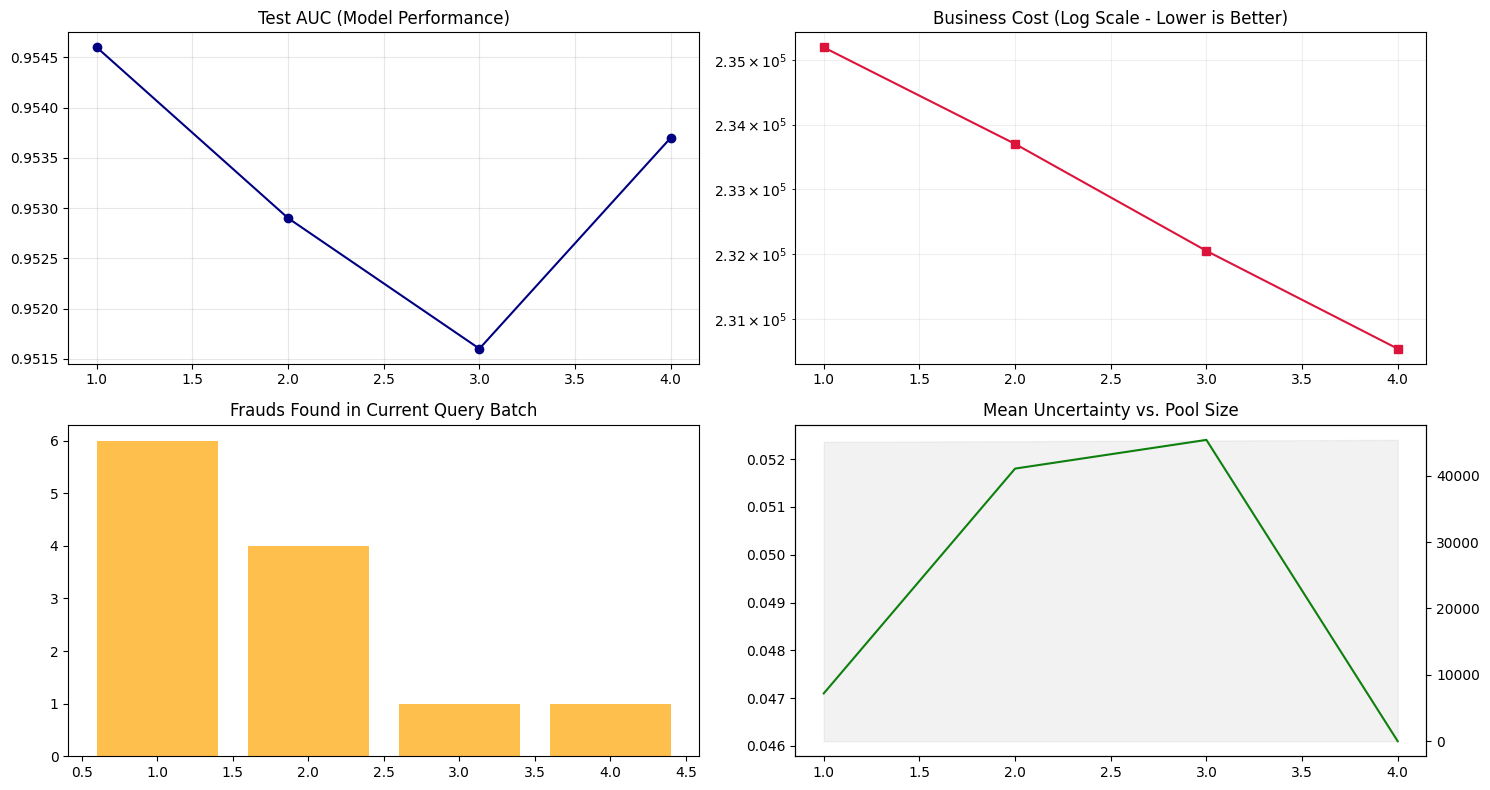

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

# --- INITIALIZE LIVE PLOT ---
# Set up a multi-panel figure
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.ion() # Turn on interactive mode

# ── AL Query Log CSV ─────────────────────────────────────────
AL_QUERY_LOG_CSV = "al_queried_labels.csv"

# Wipe any previous run's file so we start fresh each full AL run
import os
if os.path.exists(AL_QUERY_LOG_CSV):
    os.remove(AL_QUERY_LOG_CSV)
    print(f"🗑️  Cleared previous '{AL_QUERY_LOG_CSV}'")

print(f"📝 AL queries will be appended to '{AL_QUERY_LOG_CSV}' each loop.")


al_log = []

print(f"\n{'═'*65}")
print(f"  Starting Active Learning — {N_AL_LOOPS} loops × {N_QUERY_PER_LOOP} queries")
print(f"{'═'*65}\n")
print(f'  Number of rows in df_remaining_unlabeled_pool = {len(df_remaining_unlabeled_pool)}')

for al_loop in tqdm(range(N_AL_LOOPS), desc="AL Loops", unit="loop"):
    # ── Slice this loop's non-overlapping subsample ───────────────────────
    chunk_start = al_loop * N_SUBSAMPLE
    chunk_end   = chunk_start + N_SUBSAMPLE
    df_chunk    = df_remaining_unlabeled_pool.drop(columns=[TARGET_COL]).iloc[chunk_start:chunk_end]   # view, not copy yet

    # ── STEP 1: Score the subsample ───────────────────────────────────────
    X_unlabeled     = df_chunk.drop(columns=[SUM_INSURED_COL])
    proba_unlabeled = current_model.predict(
        xgb.DMatrix(X_unlabeled),
        iteration_range=(0, current_model.best_iteration + 1)
    )    # returns probabilities directly (binary:logistic)
    si_pool_vals = df_chunk[SUM_INSURED_COL].values.astype(np.float64)

    # ── STEP 2: Select top-N most uncertain rows ──────────────────────────
    # -- cost_weighted: uncertainty scaled by insured amount --
    uncertainty = 0.5 - np.abs(proba_unlabeled - 0.5)
    norm_cost = si_pool_vals / (si_pool_vals.max() + 1)
    scores = uncertainty * norm_cost
    query_local_idx = np.argsort(-scores)[:N_QUERY_PER_LOOP]

    # -- uncertainty: closest to decision boundary --
    # uncertainty = np.abs(proba_unlabeled - 0.5)
    # query_local_idx = np.argsort(uncertainty)[:N_QUERY_PER_LOOP]

    # -- diversity: k-means cluster + uncertainty (requires: from sklearn.cluster import MiniBatchKMeans) --
    # from sklearn.preprocessing import StandardScaler
    # X_scaled = StandardScaler().fit_transform(X_unlabeled)
    # kmeans = MiniBatchKMeans(n_clusters=min(N_QUERY_PER_LOOP, len(X_scaled)//2), random_state=42, batch_size=256).fit(X_scaled)
    # dists = np.min(kmeans.transform(X_scaled), axis=1)
    # scores = (1 - np.abs(2*proba_unlabeled - 1)) + 0.5*(dists/(dists.max()+1e-6))
    # query_local_idx = np.argsort(-scores)[:N_QUERY_PER_LOOP]

    # ── End strategies ────────────────────────────────────────────────────

    # query_local_idx is relative to df_chunk; grab the actual rows
    query_df          = df_chunk.iloc[query_local_idx].copy()
    query_proba       = proba_unlabeled[query_local_idx]
    query_uncertainty = scores[query_local_idx]

    query_df["al_pred_proba"]  = query_proba
    query_df["al_uncertainty"] = query_uncertainty

    # # ── STEP 3: In-memory unlabeled_oracle label lookup──
    # Join query_df against unlabeled_oracle on all feature/meta columns (excludes al_pred_proba,
    # al_uncertainty, and TARGET_COL which doesn't exist in query_df yet)
    merge_cols = [c for c in unlabeled_oracle_join_cols if c in query_df.columns]

    newly_labeled = pd.merge(
            query_df,
            df_unlabeled_oracle[unlabeled_oracle_join_cols + [TARGET_COL]],
            on=merge_cols,
            how="left"
        )

    # print(newly_labeled.columns)
    assert newly_labeled[TARGET_COL].notna().all(), \
        (f"Loop {al_loop+1}: {newly_labeled[TARGET_COL].isna().sum()} rows "
         f"failed oracle lookup — check that UNLABELED_CSV rows match the pool exactly.")

    # ── SAVE QUERIED LABELS TO CSV ────────────────────────────
    # newly_labeled has features + al_pred_proba + al_uncertainty + fraud_label (oracle)
    cols_to_save = df_labeled.columns.tolist() + ["al_pred_proba", "al_uncertainty"]
    save_df = newly_labeled[cols_to_save].copy()

    write_header = not os.path.exists(AL_QUERY_LOG_CSV)  # header only on first write
    save_df.to_csv(AL_QUERY_LOG_CSV, mode="a", header=write_header, index=False)
    # ─────────────────────────────────────────────────────────

    # ── STEP 4: Expand training pool ─────────────────────────────────────
    FEATURE_COLS = [c for c in df_labeled.columns if c not in [TARGET_COL, SUM_INSURED_COL]]
    X_new  = newly_labeled[FEATURE_COLS].values
    y_new  = newly_labeled[TARGET_COL].values.astype(np.int32)
    si_new = newly_labeled[SUM_INSURED_COL].values.astype(np.float64)

    X_train_current  = pd.concat([X_train_current,
                                   pd.DataFrame(X_new, columns=FEATURE_COLS)],
                                   ignore_index=True)
    y_train_current  = np.concatenate([y_train_current, y_new])
    si_train_current = np.concatenate([si_train_current, si_new])


    # ── STEP 5: Retrain model on expanded pool ────────────────────────────
    current_model = build_and_train_model(
        xgb_params, N_ESTIMATORS, THRESHOLD, X_train_current, y_train_current, si_train_current
    )

    # ── STEP 6: Compute train-set stats for progress tracking ─────────────
    test_proba = current_model.predict(
        xgb.DMatrix(c2_test_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])),
        iteration_range=(0, current_model.best_iteration + 1)
    )
    test_cost = compute_business_cost(c2_test_data[TARGET_COL].values.astype(np.int32), test_proba,
                                        c2_test_data[SUM_INSURED_COL].values.astype(np.float64), THRESHOLD)
    test_auc  = roc_auc_score(c2_test_data[TARGET_COL].values.astype(np.int32), test_proba)

    loop_stats = {
        "loop"                : al_loop + 1,
        "train_pool_size"     : len(y_train_current),
        "unlabeled_remaining" : len(df_remaining_unlabeled_pool) - chunk_end,
        "fraud_in_query"      : int(y_new.sum()),
        "mean_uncertainty"    : round(float(query_uncertainty.mean()), 4),
        "test_auc"           : round(test_auc, 4),
        "test_business_cost" : round(test_cost, 2),
    }
    al_log.append(loop_stats)

    # ── STEP 7: LIVE PLOT UPDATE ────────────────────────────────────────
    df_temp = pd.DataFrame(al_log)
    clear_output(wait=True)

    fig, axes = plt.subplots(2, 2, figsize=(15, 8))

    # Plot 1: AUC Progression
    axes[0, 0].plot(df_temp['loop'], df_temp['test_auc'], marker='o', color='navy')
    axes[0, 0].set_title('Test AUC (Model Performance)')
    axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: Business Cost
    axes[0, 1].plot(df_temp['loop'], df_temp['test_business_cost'], marker='s', color='crimson')
    axes[0, 1].set_yscale('log')  # <--- LOG SCALE APPLIED HERE
    axes[0, 1].set_title('Business Cost (Log Scale - Lower is Better)')
    axes[0, 1].grid(True, which="both", ls="-", alpha=0.2) # "both" shows minor gridlines for log scale

    # Plot 3: Fraud Detection Rate in Query
    axes[1, 0].bar(df_temp['loop'], df_temp['fraud_in_query'], color='orange', alpha=0.7)
    axes[1, 0].set_title('Frauds Found in Current Query Batch')

    # Plot 4: Uncertainty & Pool Size
    ax2 = axes[1, 1].twinx()
    axes[1, 1].plot(df_temp['loop'], df_temp['mean_uncertainty'], color='green', label='Uncertainty')
    ax2.fill_between(df_temp['loop'], df_temp['train_pool_size'], color='gray', alpha=0.1, label='Pool Size')
    axes[1, 1].set_title('Mean Uncertainty vs. Pool Size')

    plt.tight_layout()
    plt.show()

In [ ]:
# ── Save final retrained XGBoost booster ─────────────────────
current_model.save_model(FINAL_MODEL_PATH)
print(f"✅ Final AL model saved → '{FINAL_MODEL_PATH}'")

# ── AL progression table ─────────────────────────────────────
df_log = pd.DataFrame(al_log)
print(f"\n{'─'*90}")
print(f"   Active Learning Progression Summary")
print(f"{'─'*90}")
print(df_log.to_string(index=False))
print(f"{'─'*90}")

# ── COMPREHENSIVE COMPARISON ─────────────────────────────────
final_auc  = df_log["test_auc"].iloc[-1]
final_cost = df_log["test_business_cost"].iloc[-1]
final_pool = df_log["train_pool_size"].iloc[-1]
total_frauds_found = df_log["fraud_in_query"].sum()

print(f"\n{'═'*65}")
print(f"   BASELINE vs. FINAL ACTIVE LEARNING MODEL")
print(f"{'═'*65}")

comparison_data = {
    "Metric": ["AUC", "Business Cost", "Fraud Found in AL"],
    "Baseline": [f"{baseline_auc:.4f}", f"${baseline_cost:,.2f}", "-"],
    "AL Final": [f"{final_auc:.4f}", f"${final_cost:,.2f}", f"{total_frauds_found}"],
    "Delta": [f"{final_auc - baseline_auc:+.4f}",
              f"${final_cost - baseline_cost:+,.2f}",
              "N/A"]
}

print(pd.DataFrame(comparison_data).to_string(index=False))
print(f"{'═'*65}")

improvement_pct = ((baseline_cost - final_cost) / baseline_cost) * 100
print(f"💡 Summary: AL reduced business cost by {improvement_pct:.2f}%")
print(f"   The model was enriched with {total_frauds_found} high-value fraud cases.")

✅ Final AL model saved → 'al_final_model.json'

──────────────────────────────────────────────────────────────────────────────────────────
   Active Learning Progression Summary
──────────────────────────────────────────────────────────────────────────────────────────
 loop  train_pool_size  unlabeled_remaining  fraud_in_query  mean_uncertainty  test_auc  test_business_cost
    1            45100                18000               6            0.0471    0.9546            235200.0
    2            45200                16000               4            0.0518    0.9529            233700.0
    3            45300                14000               1            0.0524    0.9516            232050.0
    4            45400                12000               1            0.0461    0.9537            230550.0
    5            45500                10000               4            0.0434    0.9537            229650.0
    6            45600                 8000               1            0.0455    0.

## Non sequential branch

In [ ]:
# Randomly sample 1,000 points
df_sampled = df_remaining_unlabeled.sample(n=1000, random_state=60)

# Verify the shape
print(f"New shape: {df_sampled.shape}")
# ── Working copies (mutated each loop) ───────────────────────

# ── Load tuned hyper-parameters ──────────────────────────────
xgb_params, N_ESTIMATORS, THRESHOLD = load_params_from_json(BEST_PARAMS_JSON)

print(f"[BASELINE] Loaded params from '{BEST_PARAMS_JSON}'")
print(f"  Threshold : {THRESHOLD}")
print(f"  XGB params:")
for k, v in xgb_params.items():
    print(f"    {k:<25} = {v}")

# ── Working copies (mutated each loop) ───────────────────────
current_model   = baseline_model           # starts as baseline (xgb.Booster), updated each loop
X_pool = c1_train_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])            # grows as new labels arrive
y_pool = c1_train_data[TARGET_COL].values.astype(np.int32)
si_pool = c1_train_data[SUM_INSURED_COL].values.astype(np.float64)


# ── Train baseline model on full labeled pool ─────────────────
print("\n[BASELINE] Training baseline XGBoost on labeled pool …")
baseline_model = build_and_train_model(xgb_params, N_ESTIMATORS, THRESHOLD, X_pool, y_pool, si_pool)

current_model   = baseline_model           # starts as baseline (xgb.Booster), updated each loop
X_train_current = X_pool.copy()            # grows as new labels arrive
y_train_current = y_pool.copy()
si_train_current = si_pool.copy()
df_sampled_pool = df_sampled.copy()    # shrinks as rows are queried

New shape: (1000, 44)
[BASELINE] Loaded params from 'best_params.json'
  Threshold : 0.10854643368675157
  XGB params:
    max_depth                 = 5
    min_child_weight          = 4
    gamma                     = 0.45606998421703593
    learning_rate             = 0.12448918446337819
    subsample                 = 0.5998368910791798
    colsample_bytree          = 0.708540663048167
    colsample_bylevel         = 0.7554487413172255
    reg_alpha                 = 2.4298880728901692e-08
    reg_lambda                = 0.0019275890163896973

[BASELINE] Training baseline XGBoost on labeled pool …


In [ ]:
# ── Expand training pool ─────────────────────────
X_new  = df_sampled_pool.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_new  = df_sampled_pool[TARGET_COL].values.astype(np.int32)
si_new = df_sampled_pool[SUM_INSURED_COL].values.astype(np.float64)

X_train_current  = pd.concat([X_train_current, X_new],
                                ignore_index=True)
y_train_current  = np.concatenate([y_train_current, y_new])
si_train_current = np.concatenate([si_train_current, si_new])

# ── Retrain model on expanded pool ───────────────
current_model = build_and_train_model(
    xgb_params, N_ESTIMATORS, THRESHOLD, X_train_current, y_train_current, si_train_current
)

test_proba = current_model.predict(
    xgb.DMatrix(c2_test_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])),
    iteration_range=(0, current_model.best_iteration + 1)
)
test_cost = compute_business_cost(c2_test_data[TARGET_COL].values.astype(np.int32), test_proba,
                                    c2_test_data[SUM_INSURED_COL].values.astype(np.float64), THRESHOLD)
test_auc  = roc_auc_score(c2_test_data[TARGET_COL].values.astype(np.int32), test_proba)

nsl_log = []
loop_stats = {
    "train_pool_size"   : len(y_train_current),
    "fraud_in_query"    : int(y_new.sum()),
    "test_auc"         : round(test_auc, 4),
    "test_business_cost": round(test_cost, 2),
}
nsl_log.append(loop_stats)
print(  f"train_pool={loop_stats['train_pool_size']:,}  "
        f"fraud_in_query={loop_stats['fraud_in_query']}  "
        f"AUC={loop_stats['test_auc']:.4f}  "
        f"biz_cost={loop_stats['test_business_cost']:,.0f}  ")

train_pool=46,000  fraud_in_query=27  AUC=0.9542  biz_cost=231,750  


In [ ]:
# ── Save final retrained XGBoost booster ─────────────────────
current_model.save_model(FINAL_NON_SEQUENTIAL_MODEL_PATH)
print(f"✅ Final NSL model saved → '{FINAL_NON_SEQUENTIAL_MODEL_PATH}'")

# ── NSL progression table ─────────────────────────────────────
df_log = pd.DataFrame(nsl_log)
print(f"\n{'─'*90}")
print(f"  Non-Sequential Learning Progression Summary")
print(f"{'─'*90}")
print(df_log.to_string(index=False))
print(f"{'─'*90}")

# ── Delta vs baseline ─────────────────────────────────────────
final_auc  = df_log["test_auc"].iloc[-1]
final_cost = df_log["test_business_cost"].iloc[-1]

print(f"\n  Baseline → Final NSL model (train-set, indicative only)")
print(f"  AUC          : {final_auc:.4f}  ")
print(f"  AUC          : {baseline_auc:.4f}  →  {final_auc:.4f}  "
      f"(Δ {final_auc - baseline_auc:+.4f})")
print(f"  Business cost: {baseline_cost:,.0f}  →  {final_cost:,.0f}  "
      f"(Δ {final_cost - baseline_cost:+,.0f})")

print(f"\n💡 Next step: evaluate '{FINAL_NON_SEQUENTIAL_MODEL_PATH}' on a held-out labeled test set.")
print(f"   Load with: booster = xgb.Booster(); "
      f"booster.load_model('{FINAL_NON_SEQUENTIAL_MODEL_PATH}')")

✅ Final NSL model saved → 'nonsequential_final_model.json'

──────────────────────────────────────────────────────────────────────────────────────────
  Non-Sequential Learning Progression Summary
──────────────────────────────────────────────────────────────────────────────────────────
 train_pool_size  fraud_in_query  test_auc  test_business_cost
           46000              27    0.9542            231750.0
──────────────────────────────────────────────────────────────────────────────────────────

  Baseline → Final NSL model (train-set, indicative only)
  AUC          : 0.9542  
  AUC          : 0.9533  →  0.9542  (Δ +0.0009)
  Business cost: 232,950  →  231,750  (Δ -1,200)

💡 Next step: evaluate 'nonsequential_final_model.json' on a held-out labeled test set.
   Load with: booster = xgb.Booster(); booster.load_model('nonsequential_final_model.json')


## Comparison of AL and Non-sequential

### **case2 (test)**

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  FINAL EVALUATION — AL model vs Non-Sequential model
#  on held-out df_final_test (never seen during training or AL)
# ══════════════════════════════════════════════════════════════════

X_test_final  = c2_test_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_test_final  = c2_test_data[TARGET_COL].values.astype(np.int32)
si_test_final = c2_test_data[SUM_INSURED_COL].values.astype(np.float64)

dtest_final   = xgb.DMatrix(X_test_final)

print(f"[FINAL TEST SET] {len(c2_test_data):,} rows | "
      f"fraud={y_test_final.sum():,} ({100*y_test_final.mean():.2f}%)")


# ── Helper: compute all metrics for one booster ───────────────────
def evaluate_model(booster, dmat, y_true, si_vals, threshold, label):
    y_proba = booster.predict(dmat, iteration_range=(0, booster.best_iteration + 1))
    y_pred  = (y_proba >= threshold).astype(int)

    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))

    precision   = tp / max(tp + fp, 1)
    recall      = tp / max(tp + fn, 1)
    f1          = 2 * precision * recall / max(precision + recall, 1e-9)
    auc         = roc_auc_score(y_true, y_proba)
    biz_cost    = compute_business_cost(y_true, y_proba, si_vals, threshold)
    cost_per_row = biz_cost / len(y_true)

    print(f"\n{'═'*60}")
    print(f"  {label}")
    print(f"{'═'*60}")
    print(f"  Threshold       : {threshold:.4f}")
    print(f"  AUC-ROC         : {auc:.4f}")
    print(f"  Business cost   : {biz_cost:,.2f}   (per row: {cost_per_row:,.4f})")
    print(f"  TP / FP / TN / FN : {tp} / {fp} / {tn} / {fn}")
    print(f"  Precision       : {precision:.4f}")
    print(f"  Recall          : {recall:.4f}")
    print(f"  F1              : {f1:.4f}")
    print(f"{'═'*60}")

    return {
        "model"         : label,
        "auc"           : round(auc, 4),
        "biz_cost"      : round(biz_cost, 2),
        "cost_per_row"  : round(cost_per_row, 4),
        "tp"            : tp, "fp": fp, "tn": tn, "fn": fn,
        "precision"     : round(precision, 4),
        "recall"        : round(recall, 4),
        "f1"            : round(f1, 4),
    }


# ── Load both models ──────────────────────────────────────────────
booster_al        = xgb.Booster(); booster_al.load_model(FINAL_MODEL_PATH)
booster_ns        = xgb.Booster(); booster_ns.load_model(FINAL_NON_SEQUENTIAL_MODEL_PATH)
booster_baseline  = xgb.Booster(); booster_baseline.load_model(FINAL_NON_SEQUENTIAL_MODEL_PATH)


# ── Evaluate ──────────────────────────────────────────────────────
stats_al = evaluate_model(booster_al, dtest_final, y_test_final, si_test_final,
                           THRESHOLD, label="AL Model (sequential, final)")
stats_ns = evaluate_model(booster_ns, dtest_final, y_test_final, si_test_final,
                           THRESHOLD, label="Non-Sequential Model (random 1k batch)")


# ── Side-by-side comparison table ────────────────────────────────
df_compare = pd.DataFrame([stats_al, stats_ns]).set_index("model").T
print(f"\n{'─'*70}")
print(f"  Head-to-head comparison on final test set ({len(y_test_final):,} rows)")
print(f"{'─'*70}")
print(df_compare.to_string())
print(f"{'─'*70}")

# ── Delta: AL vs Non-Sequential ───────────────────────────────────
delta_auc  = stats_al["auc"]      - stats_ns["auc"]
delta_cost = stats_al["biz_cost"] - stats_ns["biz_cost"]
delta_rec  = stats_al["recall"]   - stats_ns["recall"]
delta_f1   = stats_al["f1"]       - stats_ns["f1"]

print(f"\n  Δ AL − Non-Sequential (positive = AL better for AUC/recall/f1, lower for cost)")
print(f"  AUC          : {delta_auc:+.4f}")
print(f"  Business cost: {delta_cost:+,.2f}   {'✅ AL cheaper' if delta_cost < 0 else '❌ AL more expensive'}")
print(f"  Recall       : {delta_rec:+.4f} ")
print(f"  F1           : {delta_f1:+.4f}")

[FINAL TEST SET] 10,000 rows | fraud=300 (3.00%)

════════════════════════════════════════════════════════════
  AL Model (sequential, final)
════════════════════════════════════════════════════════════
  Threshold       : 0.1085
  AUC-ROC         : 0.9536
  Business cost   : 228,300.00   (per row: 22.8300)
  TP / FP / TN / FN : 300 / 1322 / 8378 / 0
  Precision       : 0.1850
  Recall          : 1.0000
  F1              : 0.3122
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  Non-Sequential Model (random 1k batch)
════════════════════════════════════════════════════════════
  Threshold       : 0.1085
  AUC-ROC         : 0.9542
  Business cost   : 231,750.00   (per row: 23.1750)
  TP / FP / TN / FN : 300 / 1345 / 8355 / 0
  Precision       : 0.1824
  Recall          : 1.0000
  F1              : 0.3085
════════════════════════════════════════════════════════════

────────────────────────────────────────────────

### Out-of-sample (OOS) test

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  FINAL EVALUATION — Non-Sequential vs AL
# ══════════════════════════════════════════════════════════════════

# ── Step 1: Build final held-out test set (never seen in training or AL) ─────

df_sampled               = df_remaining_unlabeled.sample(n=1000, random_state=60)
df_unlabeled_al_samples  = pd.read_csv('/content/al_queried_labels.csv')
df_unlabeled             = pd.read_csv('/content/unlabeled_synthetic_insurance_claims_with_fraud_3%_label.csv')

# Union of ALL rows ever seen (training pool, AL queries, random sample)
seen = pd.concat([
    df_sampled[df_unlabeled.columns],
    df_unlabeled_al_samples[df_unlabeled.columns],
], ignore_index=True).drop_duplicates()

# Anti-join: keep only rows in df_unlabeled that were never seen
merge_cols = df_unlabeled.columns.tolist()

df_final_test = (
    df_unlabeled
    .merge(seen, on=merge_cols, how="left", indicator=True)
    .query('_merge == "left_only"')
    .drop(columns="_merge")
    .reset_index(drop=True)
)

print(f"df_unlabeled total rows      : {len(df_unlabeled):,}")
print(f"seen rows (union, deduped)   : {len(seen):,}")
print(f"final held-out test rows     : {len(df_final_test):,}")
print(f"(gap = internal dupes in df_unlabeled: "
      f"{len(df_unlabeled) - len(seen) - len(df_final_test):,})")

# ── Step 2: Build DMatrix for final test ──────────────────────────────────────
X_test_final  = df_final_test.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_test_final  = df_final_test[TARGET_COL].values.astype(np.int32)
si_test_final = df_final_test[SUM_INSURED_COL].values.astype(np.float64)
dtest_final   = xgb.DMatrix(X_test_final)

print(f"\n[FINAL TEST SET] {len(df_final_test):,} rows | "
      f"fraud={y_test_final.sum():,} ({100*y_test_final.mean():.2f}%)")


# ── Step 3: Evaluation helper ─────────────────────────────────────────────────
def evaluate_model(booster, dmat, y_true, si_vals, threshold, label):
    y_proba = booster.predict(dmat, iteration_range=(0, booster.best_iteration + 1))
    y_pred  = (y_proba >= threshold).astype(int)

    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))

    precision    = tp / max(tp + fp, 1)
    recall       = tp / max(tp + fn, 1)
    f1           = 2 * precision * recall / max(precision + recall, 1e-9)
    auc          = roc_auc_score(y_true, y_proba)
    biz_cost     = compute_business_cost(y_true, y_proba, si_vals, threshold)
    cost_per_row = biz_cost / max(len(y_true), 1)

    print(f"\n{'═'*62}")
    print(f"  {label}")
    print(f"{'═'*62}")
    print(f"  Threshold         : {threshold:.4f}")
    print(f"  AUC-ROC           : {auc:.4f}")
    print(f"  Business cost     : {biz_cost:>15,.2f}")
    print(f"  Cost per row      : {cost_per_row:>15,.4f}")
    print(f"  TP / FP / TN / FN : {tp} / {fp} / {tn} / {fn}")
    print(f"  Precision         : {precision:.4f}")
    print(f"  Recall            : {recall:.4f}")
    print(f"  F1                : {f1:.4f}")
    print(f"{'═'*62}")

    return {
        "model"        : label,
        "auc"          : round(auc, 4),
        "biz_cost"     : round(biz_cost, 2),
        "cost_per_row" : round(cost_per_row, 4),
        "tp"           : tp, "fp": fp, "tn": tn, "fn": fn,
        "precision"    : round(precision, 4),
        "recall"       : round(recall, 4),
        "f1"           : round(f1, 4),
    }


# ── Step 4: Load both models ──────────────────────────────────────────────────
booster_ns = xgb.Booster(); booster_ns.load_model(FINAL_NON_SEQUENTIAL_MODEL_PATH)
booster_al = xgb.Booster(); booster_al.load_model(FINAL_MODEL_PATH)


# ── Step 5: Evaluate both ────────────────────────────────────────────────────
stats_ns = evaluate_model(
    booster_ns, dtest_final, y_test_final, si_test_final,
    THRESHOLD, label="Non-Sequential (random 1k unlabeled)"
)
stats_al = evaluate_model(
    booster_al, dtest_final, y_test_final, si_test_final,
    THRESHOLD, label="Active Learning (sequential, 10 loops)"
)


# ── Step 6: Side-by-side comparison table ────────────────────────────────────
df_compare = (
    pd.DataFrame([stats_ns, stats_al])
    .set_index("model")
    .T
)

print(f"\n{'─'*80}")
print(f"  Head-to-head comparison on final held-out test set ({len(y_test_final):,} rows)")
print(f"{'─'*80}")
print(df_compare.to_string())
print(f"{'─'*80}")


# ── Step 7: Delta — AL vs Non-Sequential ─────────────────────────────────────
def delta_row(stats_a, stats_b, label_a, label_b):
    print(f"\n  Δ  {label_a}  vs  {label_b}  (positive = {label_a} better for AUC/recall/f1)")
    d_auc  = stats_a["auc"]      - stats_b["auc"]
    d_cost = stats_a["biz_cost"] - stats_b["biz_cost"]
    d_rec  = stats_a["recall"]   - stats_b["recall"]
    d_f1   = stats_a["f1"]       - stats_b["f1"]
    print(f"  AUC          : {d_auc:+.4f}")
    print(f"  Business cost: {d_cost:+,.2f}   "
          f"{'✅ cheaper' if d_cost < 0 else '❌ more expensive'}")
    print(f"  Recall       : {d_rec:+.4f}")
    print(f"  F1           : {d_f1:+.4f}")

delta_row(stats_al, stats_ns, "AL", "Non-Sequential")

df_unlabeled total rows      : 30,000
seen rows (union, deduped)   : 1,948
final held-out test rows     : 28,072
(gap = internal dupes in df_unlabeled: -20)

[FINAL TEST SET] 28,072 rows | fraud=843 (3.00%)

══════════════════════════════════════════════════════════════
  Non-Sequential (random 1k unlabeled)
══════════════════════════════════════════════════════════════
  Threshold         : 0.1085
  AUC-ROC           : 0.9567
  Business cost     :      620,400.00
  Cost per row      :         22.1003
  TP / FP / TN / FN : 843 / 3574 / 23655 / 0
  Precision         : 0.1909
  Recall            : 1.0000
  F1                : 0.3205
══════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════
  Active Learning (sequential, 10 loops)
══════════════════════════════════════════════════════════════
  Threshold         : 0.1085
  AUC-ROC           : 0.9554
  Business cost     :      609,900.00
  Cost per row      :         21.7

### Comparison of AL and Non-sequential with Baseline

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  FINAL EVALUATION — Baseline vs Non-Sequential vs AL
# ══════════════════════════════════════════════════════════════════

# ── Step 0: Save the baseline model (add this right after baseline_model is trained above) ──
# If you still have `baseline_model` in memory, just save it now:
BASELINE_MODEL_PATH = "baseline_model.json"
baseline_model.save_model(BASELINE_MODEL_PATH)
print(f"✅ Baseline model saved → '{BASELINE_MODEL_PATH}'")


# ── Step 1: Build final held-out test set (never seen in training or AL) ─────

df_sampled               = df_remaining_unlabeled.sample(n=1000, random_state=60)
df_unlabeled_al_samples  = pd.read_csv('/content/al_queried_labels.csv')
df_unlabeled             = pd.read_csv('/content/unlabeled_synthetic_insurance_claims_with_fraud_3%_label.csv')

# Union of ALL rows ever seen (training pool, AL queries, random sample, c2_test_data)
seen = pd.concat([
    df_sampled[df_unlabeled.columns],
    df_unlabeled_al_samples[df_unlabeled.columns],
    c2_test_data[df_unlabeled.columns],
], ignore_index=True).drop_duplicates()

# Anti-join: keep only rows in df_unlabeled that were never seen
merge_cols = df_unlabeled.columns.tolist()

df_final_test = (
    df_unlabeled
    .merge(seen, on=merge_cols, how="left", indicator=True)
    .query('_merge == "left_only"')
    .drop(columns="_merge")
    .reset_index(drop=True)
)

# Note: df_unlabeled may have duplicate rows internally, so
# len(seen) + len(df_final_test) can differ from len(df_unlabeled)
print(f"df_unlabeled total rows      : {len(df_unlabeled):,}")
print(f"seen rows (union, deduped)   : {len(seen):,}")
print(f"final held-out test rows     : {len(df_final_test):,}")
print(f"(gap = internal dupes in df_unlabeled: "
      f"{len(df_unlabeled) - len(seen) - len(df_final_test):,})")

# ── Step 2: Build DMatrix for final test ──────────────────────────────────────
X_test_final  = df_final_test.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_test_final  = df_final_test[TARGET_COL].values.astype(np.int32)
si_test_final = df_final_test[SUM_INSURED_COL].values.astype(np.float64)
dtest_final   = xgb.DMatrix(X_test_final)

print(f"\n[FINAL TEST SET] {len(df_final_test):,} rows | "
      f"fraud={y_test_final.sum():,} ({100*y_test_final.mean():.2f}%)")


# ── Step 3: Evaluation helper ─────────────────────────────────────────────────
def evaluate_model(booster, dmat, y_true, si_vals, threshold, label):
    y_proba = booster.predict(dmat, iteration_range=(0, booster.best_iteration + 1))
    y_pred  = (y_proba >= threshold).astype(int)

    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))

    precision    = tp / max(tp + fp, 1)
    recall       = tp / max(tp + fn, 1)
    f1           = 2 * precision * recall / max(precision + recall, 1e-9)
    auc          = roc_auc_score(y_true, y_proba)
    biz_cost     = compute_business_cost(y_true, y_proba, si_vals, threshold)
    cost_per_row = biz_cost / max(len(y_true), 1)

    print(f"\n{'═'*62}")
    print(f"  {label}")
    print(f"{'═'*62}")
    print(f"  Threshold         : {threshold:.4f}")
    print(f"  AUC-ROC           : {auc:.4f}")
    print(f"  Business cost     : {biz_cost:>15,.2f}")
    print(f"  Cost per row      : {cost_per_row:>15,.4f}")
    print(f"  TP / FP / TN / FN : {tp} / {fp} / {tn} / {fn}")
    print(f"  Precision         : {precision:.4f}")
    print(f"  Recall            : {recall:.4f}")
    print(f"  F1                : {f1:.4f}")
    print(f"{'═'*62}")

    return {
        "model"        : label,
        "auc"          : round(auc, 4),
        "biz_cost"     : round(biz_cost, 2),
        "cost_per_row" : round(cost_per_row, 4),
        "tp"           : tp, "fp": fp, "tn": tn, "fn": fn,
        "precision"    : round(precision, 4),
        "recall"       : round(recall, 4),
        "f1"           : round(f1, 4),
    }


# ── Step 4: Load all three models ────────────────────────────────────────────
booster_baseline = xgb.Booster(); booster_baseline.load_model(BASELINE_MODEL_PATH)
booster_ns       = xgb.Booster(); booster_ns.load_model(FINAL_NON_SEQUENTIAL_MODEL_PATH)
booster_al       = xgb.Booster(); booster_al.load_model(FINAL_MODEL_PATH)


# ── Step 5: Evaluate all three ───────────────────────────────────────────────
stats_baseline = evaluate_model(
    booster_baseline, dtest_final, y_test_final, si_test_final,
    THRESHOLD, label="Baseline (labeled pool only)"
)
stats_ns = evaluate_model(
    booster_ns, dtest_final, y_test_final, si_test_final,
    THRESHOLD, label="Non-Sequential (random 1k unlabeled)"
)
stats_al = evaluate_model(
    booster_al, dtest_final, y_test_final, si_test_final,
    THRESHOLD, label="Active Learning (sequential, 10 loops)"
)


# ── Step 6: Side-by-side comparison table ────────────────────────────────────
df_compare = (
    pd.DataFrame([stats_baseline, stats_ns, stats_al])
    .set_index("model")
    .T
)

print(f"\n{'─'*80}")
print(f"  Head-to-head comparison on final held-out test set ({len(y_test_final):,} rows)")
print(f"{'─'*80}")
print(df_compare.to_string())
print(f"{'─'*80}")


# ── Step 7: Deltas vs Baseline ───────────────────────────────────────────────
def delta_row(stats_a, stats_b, label_a, label_b):
    print(f"\n  Δ  {label_a}  vs  {label_b}  (positive = {label_a} better for AUC/recall/f1)")
    d_auc  = stats_a["auc"]      - stats_b["auc"]
    d_cost = stats_a["biz_cost"] - stats_b["biz_cost"]
    d_rec  = stats_a["recall"]   - stats_b["recall"]
    d_f1   = stats_a["f1"]       - stats_b["f1"]
    print(f"  AUC          : {d_auc:+.4f}")
    print(f"  Business cost: {d_cost:+,.2f}   "
          f"{'✅ cheaper' if d_cost < 0 else '❌ more expensive'}")
    print(f"  Recall       : {d_rec:+.4f}")
    print(f"  F1           : {d_f1:+.4f}")

delta_row(stats_ns, stats_baseline, "Non-Sequential", "Baseline")
delta_row(stats_al, stats_baseline, "AL",             "Baseline")
delta_row(stats_al, stats_ns,       "AL",             "Non-Sequential")

✅ Baseline model saved → 'baseline_model.json'
df_unlabeled total rows      : 30,000
seen rows (union, deduped)   : 11,948
final held-out test rows     : 18,274
(gap = internal dupes in df_unlabeled: -222)

[FINAL TEST SET] 18,274 rows | fraud=548 (3.00%)

══════════════════════════════════════════════════════════════
  Baseline (labeled pool only)
══════════════════════════════════════════════════════════════
  Threshold         : 0.1085
  AUC-ROC           : 0.9571
  Business cost     :      390,650.00
  Cost per row      :         21.3774
  TP / FP / TN / FN : 548 / 2239 / 15487 / 0
  Precision         : 0.1966
  Recall            : 1.0000
  F1                : 0.3286
══════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════
  Non-Sequential (random 1k unlabeled)
══════════════════════════════════════════════════════════════
  Threshold         : 0.1085
  AUC-ROC           : 0.9578
  Business cost     :      393,35

# New section